# 02 · 时间序列数据处理与可视化：场景化代码模板

这份 notebook 面向有限时间内的探索性研究：先确认数据的含义、质量和时间，再选择能回答具体问题的图。包含 **12 个数据处理模板 + 18 个可视化模板**，每个模板都有实际输出、中文注释、适用情形与容易误判的地方。

**使用方法：** 先运行下面的 setup；然后按目录寻找场景，复制对应代码格。所有示例使用同一份可复现的**合成数据**，并非真实市场表现。`regime` 是仿真生成时才知道的阶段标签，只用于说明图形，不能当成真实研究里事先可知的预测特征。图内文字用英文，附近文字提供中文解释，避免现场缺少中文字体。

**现场替换数据时先做三件事：**
1. 用你的数据替换 `demo_panel`，明确一行是「一个时间 × 一个对象」还是事件记录。
2. 对齐下面的数据契约；价格、收益、数量的单位必须自己确认。`asset` 不一定是金融资产，也可以是客户、机器或产品。
3. 对每个模板重新确认数据频率与信息可用时点。本例的 `252`、工作日历和月度复利都只是本例的约定。

本材料供面试前学习及在规则允许时查询。**允许上网不自动等于允许使用个人预写代码**；能否访问或复制本仓库以面试方规定为准。面试时不要使用 AI。

### 快速导航

| 数据处理 | 可视化：描述与质量 | 可视化：时序与关系 |
|---|---|---|
| [D01 审计](#D01) · [D02 类型与单位](#D02) | [V01 水平与变化](#V01) · [V02 归一化分面](#V02) | [V07 滚动均值/波动](#V07) · [V08 滚动相关](#V08) |
| [D03 重复与冲突](#D03) · [D04 缺失与覆盖](#D04) | [V03 缺失热图](#V03) · [V04 覆盖率](#V04) | [V09 相关矩阵和样本量](#V09) · [V10 滞后散点](#V10) |
| [D05 时间与日历](#D05) · [D06 收益与极值](#D06) | [V05 分布与尾部](#V05) · [V06 异常点定位](#V06) | [V11 自相关](#V11) · [V12 周内/日内季节性](#V12) |
| [D07 历史特征](#D07) · [D08 训练集拟合](#D08) | [V15 阶段与样本切分](#V15) | [V13 月度收益热图](#V13) · [V14 量价分图](#V14) |
| [D09 Point-in-time 连接](#D09) · [D10 重采样](#D10) | [V18 不规则事件](#V18) | [V16 分位组与未来目标](#V16) · [V17 回撤](#V17) |
| [D11 未来标签与 purge](#D11) · [D12 事件聚合与连接](#D12) | | |

### 数据契约与时间约定

| 字段 | 类型/单位 | 含义及限制 |
|---|---|---|
| `date` | 无时区 datetime，日频 | 本例的模拟收盘日期；无真实交易所节假日 |
| `asset` | 字符串 | Alpha / Beta / Gamma / Delta，唯一键为 `(date, asset)` |
| `price` | 正数、任意计价单位 | 合成的收益累计指数，不是真实证券价格 |
| `ret` | 小数收益 | `0.01 = 1%`；本例第一条收益未知，保留 NaN |
| `volume` | 正数、模拟数量 | 仅供演示聚合与图表；不是可成交容量 |
| `regime` | 类别 | 已知的仿真阶段，真实预测时不可直接使用 |

所有日频预测模板约定：**在日期 t 收盘后使用 t 及以前的信息，预测 t+1 起的变化**。若需要在 t 收盘前交易，必须再推迟特征或改变成交假设。

In [1]:
# SETUP 1/2：仅使用 numpy / pandas / matplotlib；建议从这一格开始运行。
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.2,
    "axes.titlesize": 12, "axes.labelsize": 10,
    "font.size": 10, "legend.frameon": False,
})
COLORS = ["#2563eb", "#e07636", "#0f8a77", "#a351a7"]
SEED = 20261007
PERIODS_PER_YEAR = 252  # 仅适用于本例近似交易日频率，不可用于任意时间序列。
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "numpy:", np.__version__, "matplotlib:", matplotlib.__version__)

Python: 3.8.20
pandas: 1.5.3 numpy: 1.24.4 matplotlib: 3.7.5


In [2]:
# SETUP 2/2：900 个模拟工作日 × 4 个对象；固定种子使结果可重现。
rng = np.random.RandomState(SEED)
dates = pd.bdate_range("2020-01-02", periods=900)
assets = ["Alpha", "Beta", "Gamma", "Delta"]
n = len(dates)
phase = np.where(np.arange(n) < 300, "calm", np.where(np.arange(n) < 590, "stress", "recovery"))
# 波动簇：当期波动依赖上一期冲击；阶段差异只用于构建教学数据。
market = np.zeros(n)
variance = np.zeros(n)
variance[0] = 0.008 ** 2
z = rng.standard_t(df=7, size=n) / np.sqrt(7 / 5)
for t in range(1, n):
    base_vol = 0.007 if phase[t] == "calm" else (0.018 if phase[t] == "stress" else 0.010)
    variance[t] = 0.05 * base_vol ** 2 + 0.12 * market[t-1] ** 2 + 0.83 * variance[t-1]
    drift = -0.00035 if phase[t] == "stress" else 0.00035
    market[t] = drift + np.sqrt(variance[t]) * z[t]
parts = []
for j, asset in enumerate(assets):
    idio = rng.standard_t(8, n) * (0.003 + 0.001 * j)
    season = 0.0006 * np.sin(2 * np.pi * np.arange(n) / (50 + 10 * j))
    r = (0.7 + 0.15 * j) * market + idio + season + 0.0001 * (j-1)
    r = np.clip(r, -0.25, 0.25)  # 生成过程的约束；不是对实际研究收益的裁剪建议。
    p = 100 * np.cumprod(1 + r)
    vol = rng.lognormal(12 + 0.2 * j, 0.35, n) * (1 + 12 * np.abs(r))
    parts.append(pd.DataFrame({"date": dates, "asset": asset, "price": p,
                               "ret": pd.Series(p).pct_change(fill_method=None).values,
                               "volume": np.round(vol), "regime": phase}))
demo_panel = pd.concat(parts, ignore_index=True).sort_values(["asset", "date"]).reset_index(drop=True)
assert not demo_panel.duplicated(["date", "asset"]).any()
wide_ret = demo_panel.pivot(index="date", columns="asset", values="ret").sort_index()
wide_price = demo_panel.pivot(index="date", columns="asset", values="price").sort_index()
train_cutoff = dates[630]  # 只用于示范按时间切分；不是调参选出来的日期。

# 脏数据是专用副本，任何清洗都不会改写 demo_panel。
dirty_panel = demo_panel.copy()
dirty_panel = dirty_panel.loc[~((dirty_panel["asset"] == "Delta") & dirty_panel["date"].isin(dates[80:115]))].copy()
dirty_panel.loc[(dirty_panel["asset"] == "Beta") & dirty_panel["date"].isin(dates[420:440]), "price"] = np.nan
dirty_panel.loc[dirty_panel.index[::97], "volume"] = np.nan
dirty_panel.loc[(dirty_panel["asset"] == "Gamma") & (dirty_panel["date"] == dates[222]), "price"] = -5
# 人为记录错误：把某日价格写大 12 倍；原始 ret 因此不再与 price 一致。
dirty_panel.loc[(dirty_panel["asset"] == "Alpha") & (dirty_panel["date"] == dates[350]), "price"] *= 12
exact_duplicate = dirty_panel.iloc[[20]].copy()
conflicting_duplicate = dirty_panel.iloc[[50]].copy()
conflicting_duplicate["price"] *= 1.03
dirty_panel = pd.concat([dirty_panel, exact_duplicate, conflicting_duplicate], ignore_index=True)
dirty_panel = dirty_panel.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 事件级示例：不同小时不同密度；这些是模拟观测，不是固定间隔价格。
ev_rng = np.random.RandomState(SEED + 1)
ev_times = []
for day in pd.bdate_range("2023-05-01", periods=12):
    for hour in range(9, 17):
        count = ev_rng.poisson(6 if hour in (9, 16) else 2)
        secs = np.sort(ev_rng.randint(0, 3600, size=count))
        ev_times.extend(day + pd.Timedelta(hours=hour) + pd.to_timedelta(secs, unit="s"))
events = pd.DataFrame({"timestamp": pd.DatetimeIndex(ev_times)})
events["value"] = 20 + 2 * np.sin(events["timestamp"].dt.hour / 24 * 2 * np.pi) + ev_rng.normal(0, 0.4, len(events))
events["quantity"] = ev_rng.randint(1, 30, len(events))
events["asset"] = "Alpha"

display(demo_panel.head(8))
display(pd.DataFrame({"rows": [len(demo_panel), len(dirty_panel)],
                      "assets": [demo_panel["asset"].nunique(), dirty_panel["asset"].nunique()]},
                     index=["clean synthetic", "dirty exercise"]))
print("日期范围:", dates.min().date(), "至", dates.max().date(), "| 训练切分:", train_cutoff.date())

,date,asset,price,ret,volume,regime
0,2020-01-02,Alpha,99.652296,NaN,300669.0,calm
1,2020-01-03,Alpha,99.513026,-0.001398,228142.0,calm
2,2020-01-06,Alpha,99.535752,0.000228,206709.0,calm
3,2020-01-07,Alpha,100.053383,0.005200,220768.0,calm
4,2020-01-08,Alpha,100.346403,0.002929,171170.0,calm
5,2020-01-09,Alpha,100.094138,-0.002514,286083.0,calm
6,2020-01-10,Alpha,99.394715,-0.006988,343552.0,calm
7,2020-01-13,Alpha,99.026567,-0.003704,227301.0,calm


,rows,assets
clean synthetic,3600,4
dirty exercise,3567,4


日期范围: 2020-01-02 至 2023-06-14 | 训练切分: 2022-06-02


### 真实数据接入：一次替换整个数据上下文

**不能只替换 `demo_panel` 一行变量。** 本例的 `wide_ret`、`wide_price`、`dates`、`assets`、`dirty_panel` 都是 setup 生成的缓存。如果只换长表，部分图仍会显示旧合成数据。下面是集中接入代码框；它不会自动执行外部文件。完成字段映射、日历确认与重复冲突处理后，把这整个代码框复制到新格执行，再运行需要的 recipe。

```python
# 先根据实际文件路径和列名调整；不要盲目假定 price/ret/volume 的含义。
raw = pd.read_csv("your_data.csv")
raw = raw.rename(columns={"your_time_column": "date", "your_id_column": "asset"})
raw["date"] = pd.to_datetime(raw["date"], errors="raise")
dirty_panel = raw.copy()  # D01–D06 审计原始版本。

# 此处替换为你按照来源规则确认后的结果；冲突处理不应只 keep='last'。
clean = raw.copy()
assert not clean[["date", "asset"]].isna().any().any()
assert not clean.duplicated(["date", "asset"]).any(), "先按 D03 处理重复/冲突"
demo_panel = clean.sort_values(["asset", "date"]).reset_index(drop=True)
assets = sorted(demo_panel["asset"].unique())

# expected_dates 必须由真正的交易/营业/传感器日历构造，并与 date 时区一致。
# 不可默认 pd.bdate_range 等价于真实交易日历。
dates = pd.DatetimeIndex(expected_dates).sort_values().unique()
assert demo_panel["date"].isin(dates).all(), "预期日历遗漏了已观测日期"
wide_price = demo_panel.pivot(index="date", columns="asset", values="price").reindex(index=dates, columns=assets)
wide_ret = demo_panel.pivot(index="date", columns="asset", values="ret").reindex(index=dates, columns=assets)
# 如果来源只有正的复权价格、且已确认要计算相邻日历格收益，可明确选择：
# wide_ret = wide_price.pct_change(fill_method=None)
# demo_panel = demo_panel.drop(columns=["ret"], errors="ignore").merge(
#     wide_ret.rename_axis(columns="asset").stack(dropna=False).rename("ret").reset_index(),
#     on=["date", "asset"], how="left", validate="one_to_one")

train_cutoff = pd.Timestamp("YOUR_PREDEFINED_CUTOFF")  # 替换为事先确定的日期及正确时区。
PERIODS_PER_YEAR = 252  # 按真实频率与年化约定改写；不要机械保留 252。
events = None  # 清空合成事件缓存；需要事件分析时另外读入你的 timestamp/value/quantity/asset 表。
```

**数据类型不同，要选择适用的场景：**
- 只有收益而没有价格：不要伪造原始价格；可跳过价格相关模板。若构造累计指数，明确它是收益累计指数。
- 利率、价差、温度等可能为零或负数的序列：通常应考虑差分，不应套用价格收益率或回撤公式。
- 没有真实成交量：跳过 D08 中 `log_volume`、V14 量价关系，或换成有意义的活动指标并改名。
- 没有事先已知的阶段标签：不要创建假的 `regime`；V15 可以只画训练/测试切分线。
- 没有事件表：跳过 D12、V18，以及 V12 的小时图；保留日频相关部分。
- 对象不叫 Alpha/Beta：每个 recipe 顶部的对象选择要改成真实 ID。横截面对象很多时，先按明确规则选少量展示对象。

每次换数据后，重新运行所选 recipe；不要把之前数据的输出当作新数据结果。

## A · 数据处理

先问「这一行是什么、这个值何时可知」，再执行清洗。下列处理不是必须全部使用的流水线：缺失、极值和日历都需要按场景决定。每个模板都保留诊断输出，便于现场解释处理前后的差异。

<a id='D01'></a>
## D01 · 先审计：粒度、键、类型、覆盖与可疑值

**何时使用：** 刚拿到任何长表，还不知道质量和覆盖情况时。

**想回答的问题：** 一行到底表示什么？主键是否唯一？哪些对象或字段存在问题？

**输入要求：** dirty_panel；真实数据先将配置字段替换为实际列名。不要未经检查就认定 (时间, 对象) 必须唯一。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [3]:
# 候选唯一键只适用于“一对象每天一条记录”的粒度。
d01 = dirty_panel.copy()
key = ["date", "asset"]
field_audit = pd.DataFrame({"dtype": d01.dtypes.astype(str),
                            "missing_n": d01.isna().sum(),
                            "missing_pct": d01.isna().mean().mul(100).round(2),
                            "unique_n": d01.nunique(dropna=False)})
entity_audit = d01.groupby("asset").agg(
    rows=("date", "size"), first_date=("date", "min"), last_date=("date", "max"),
    unique_dates=("date", "nunique"), missing_price=("price", lambda s: s.isna().sum()),
    nonpositive_price=("price", lambda s: s.le(0).sum()))
print("shape:", d01.shape)
print("缺失键行数:", d01[key].isna().any(axis=1).sum())
print("涉及重复键的行数:", d01.duplicated(key, keep=False).sum())
print("数值列正负无穷个数:", np.isinf(d01.select_dtypes(include=np.number)).sum().to_dict())
display(field_audit)
display(entity_audit)
display(d01.loc[d01.duplicated(key, keep=False)].sort_values(key))

shape: (3567, 6)
缺失键行数: 0
涉及重复键的行数: 4
数值列正负无穷个数: {'price': 0, 'ret': 0, 'volume': 0}


,dtype,missing_n,missing_pct,unique_n
date,datetime64[ns],0,0.00,900
asset,object,0,0.00,4
price,float64,20,0.56,3547
ret,float64,4,0.11,3562
volume,float64,37,1.04,3518
regime,object,0,0.00,3


,rows,first_date,last_date,unique_dates,missing_price,nonpositive_price
asset,,,,,,
Alpha,902,2020-01-02,2023-06-14,900,0,0
Beta,900,2020-01-02,2023-06-14,900,20,0
Delta,865,2020-01-02,2023-06-14,865,0,0
Gamma,900,2020-01-02,2023-06-14,900,0,1


,date,asset,price,ret,volume,regime
528,2020-01-30,Alpha,98.150900,-0.008880,194006.0,calm
2078,2020-01-30,Alpha,98.150900,-0.008880,194006.0,calm
982,2020-03-12,Alpha,99.495819,0.006234,147861.0,calm
1116,2020-03-12,Alpha,96.597883,0.006234,147861.0,calm


**如何读结果：** `rows` 与 `unique_dates` 不同提示重复键；Gamma 的非正价格、Beta 的缺失价格和 Delta 的缺少日期是不同问题，不能统一用 fillna 解决。`missing_pct` 的分母是已出现的行，因此未出现的整行需要 D04 另外统计。

**常见误判：** `describe()` 不能替代键和覆盖审计；事件记录允许同一日有很多行。重复键是否错误必须先确认数据粒度。

<a id='D02'></a>
## D02 · 统一日期、数值和单位，同时保留解析失败记录

**何时使用：** CSV 读入后出现 object 类型、千位分隔符、百分数、混合日期或错误字符串。

**想回答的问题：** 哪些值成功转换，哪些需要核对？收益到底是 1% 还是 100%？

**输入要求：** 包含字符串日期和数值的原始表。本例 date_raw 的格式由数据说明确认；不同格式应分支解析。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [4]:
d02_raw = pd.DataFrame({"date_raw": ["2023-01-03", "2023-01-04", "bad-date", "2023-01-06"],
                       "asset_raw": [" Alpha ", "alpha", "BETA", "Beta"],
                       "price_raw": ["1,234.50", "1238.10", "N/A", "oops"],
                       "return_pct_raw": ["1.2", "-0.5", "", "2.0"]})
d02 = d02_raw.copy()
d02["date"] = pd.to_datetime(d02["date_raw"], format="%Y-%m-%d", errors="coerce")
# 统一大小写只有在业务确认 ID 大小写不敏感时才适用。
d02["asset"] = d02["asset_raw"].str.strip().str.upper()
d02["price"] = pd.to_numeric(d02["price_raw"].str.replace(",", "", regex=False), errors="coerce")
# 已由数据字典确认该列是“百分数”；显式除以 100，不根据数值大小猜单位。
d02["ret"] = pd.to_numeric(d02["return_pct_raw"], errors="coerce") / 100
invalid = d02[["date", "price"]].isna().any(axis=1)
display(d02)
display(d02.loc[invalid, ["date_raw", "price_raw", "date", "price"]])
print("需要核对的行数:", invalid.sum(), "| 不自动删除原始文本。")

,date_raw,asset_raw,price_raw,return_pct_raw,date,asset,price,ret
0,2023-01-03,Alpha,"1,234.50",1.2,2023-01-03,ALPHA,1234.5,0.012
1,2023-01-04,alpha,1238.10,-0.5,2023-01-04,ALPHA,1238.1,-0.005
2,bad-date,BETA,N/A,,NaT,BETA,NaN,NaN
3,2023-01-06,Beta,oops,2.0,2023-01-06,BETA,NaN,0.020


,date_raw,price_raw,date,price
2,bad-date,N/A,NaT,NaN
3,2023-01-06,oops,2023-01-06,NaN


需要核对的行数: 2 | 不自动删除原始文本。


**如何读结果：** NaT/NaN 是解析失败或原始缺失的标志，而不是清洗成功。原始列帮助查回输入。`return_pct_raw=1.2` 对应小数收益 0.012。

**常见误判：** 混合日/月顺序不能靠 `dayfirst` 猜；资产 ID 前导零、大小写可能有意义；欧洲数字格式 `1.234,50` 需要不同解析规则。

<a id='D03'></a>
## D03 · 完全重复与冲突重复分开处理

**何时使用：** 同一个 date/asset 多次出现，需要知道是重复导入还是价格冲突。

**想回答的问题：** 可以安全去除的完全重复有多少？冲突记录需要怎样隔离？

**输入要求：** dirty_panel，且已确认一天一个对象只能有一条记录。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [5]:
d03 = dirty_panel.copy()
exact_n = d03.duplicated().sum()
dedup_exact = d03.drop_duplicates().copy()  # 所有列完全相同才自动去重。
key = ["date", "asset"]
conflict_mask = dedup_exact.duplicated(key, keep=False)
conflicts = dedup_exact.loc[conflict_mask].sort_values(key)
# 没有可信版本号/发布时间时，不擅自 keep='last'；先隔离供核对。
usable = dedup_exact.loc[~conflict_mask].sort_values(["asset", "date"]).copy()
assert not usable.duplicated(key).any()
print("删除完全重复:", exact_n)
print("隔离冲突行:", len(conflicts), "| 暂可用行:", len(usable))
display(conflicts)
# 如有 revision_timestamp，可先确认修订在分析时点已公开，再按明确规则取版本。

删除完全重复: 1
隔离冲突行: 2 | 暂可用行: 3564


,date,asset,price,ret,volume,regime
982,2020-03-12,Alpha,99.495819,0.006234,147861.0,calm
1116,2020-03-12,Alpha,96.597883,0.006234,147861.0,calm


**如何读结果：** 本例包含一条完全重复导入和一个价格冲突的键。隔离冲突会暂时减少数据覆盖，因此下一步要记录缺口；拿到来源解释后再选择正确值。

**常见误判：** `drop_duplicates(['date','asset'], keep='last')` 只按当前行顺序选择，打乱 CSV 后结果可能改变。最终修订值还可能造成历史回看偏差。

<a id='D04'></a>
## D04 · 缺失：区分缺整行、缺字段和真实零值

**何时使用：** 要比较覆盖率、构造完整面板、计算变化或决定是否填补。

**想回答的问题：** 对象在某个预期时点没有记录，还是有记录但值为空？缺失影响多少后续收益？

**输入要求：** dirty_panel + 经过确认的 expected_dates。此处工作日只是模拟日历。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [6]:
d04 = dirty_panel.drop_duplicates().copy()
d04 = d04.loc[~d04.duplicated(["date", "asset"], keep=False)].copy()
expected_dates = dates  # 真实数据应替换成合适的交易/营业/观测日历。
expected_grid = pd.MultiIndex.from_product([expected_dates, assets], names=["date", "asset"])
observed = d04.assign(row_present=True).set_index(["date", "asset"])
aligned = observed.reindex(expected_grid)
aligned["row_present"] = aligned["row_present"].fillna(False).astype(bool)
aligned["row_absent"] = ~aligned["row_present"]
aligned["price_missing_in_present_row"] = aligned["row_present"] & aligned["price"].isna()
coverage = aligned.groupby(level="asset").agg(
    expected_n=("row_present", "size"), observed_n=("row_present", "sum"),
    absent_rows=("row_absent", "sum"), null_price_rows=("price_missing_in_present_row", "sum"))
coverage["row_coverage_pct"] = 100 * coverage["observed_n"] / coverage["expected_n"]
# 缺失后收益保留 NaN；禁止 pct_change 隐式前向填充。
p = aligned["price"].unstack("asset")
r = p.pct_change(fill_method=None)
display(coverage.round(2))
display(pd.DataFrame({"missing_price": p.isna().sum(), "missing_return": r.isna().sum()}))

,expected_n,observed_n,absent_rows,null_price_rows,row_coverage_pct
asset,,,,,
Alpha,900,899,1,0,99.89
Beta,900,900,0,20,100.00
Delta,900,865,35,0,96.11
Gamma,900,900,0,0,100.00


,missing_price,missing_return
asset,,
Alpha,1,3
Beta,20,22
Delta,35,37
Gamma,0,1


**如何读结果：** 缺一天价格通常会使当天和下一天的单期收益都不可算。Delta 的缺整行和 Beta 的字段缺失应分别解释。收益 NaN 不能替换成 0，否则会人为压低波动并掩盖停报。

**常见误判：** 对象上市前/退市后的日期不应都计作缺失。本例对象全程存在；真实分母应按对象的有效存续区间和应有日历建立。只有在意义明确时才考虑有限前向填充协变量，同时保留缺失指示器和数据年龄。

<a id='D05'></a>
## D05 · 时区、夏令时与预期日历

**何时使用：** 跨地区事件、UTC 时间戳、日内聚合、夏令时切换或频率不齐。

**想回答的问题：** 两个时间是否代表同一时刻？交易日和自然日有没有混用？

**输入要求：** 带时区的事件时间，或已知原始地区的本地时间；不明确时区不能自行猜测。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [7]:
# ISO 字符串明确携带 UTC 偏移，先统一到 UTC，再转成本地展示时区。
d05 = pd.DataFrame({"timestamp_raw": ["2023-03-10T14:30:00Z", "2023-03-13T13:30:00Z", "2023-11-06T14:30:00Z"]})
d05["utc"] = pd.to_datetime(d05["timestamp_raw"], utc=True)
d05["new_york"] = d05["utc"].dt.tz_convert("America/New_York")
# 夏令时前后 UTC 开盘小时会变，本地小时仍可相同。
d05["local_hour"] = d05["new_york"].dt.hour
display(d05)

# 原始无时区字符串必须已知地区；无法判定的夏令时重复/不存在时点显式标 NaT。
local_naive = pd.DatetimeIndex(["2023-11-05 01:30", "2023-03-12 02:30", "2023-03-13 09:30"])
localized = local_naive.tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
display(pd.DataFrame({"naive": local_naive, "localized": localized}))

expected = pd.bdate_range("2023-05-01", "2023-05-10")
observed = expected.delete(3)
print("相对模拟工作日历的缺口:", expected.difference(observed).strftime("%Y-%m-%d").tolist())

,timestamp_raw,utc,new_york,local_hour
0,2023-03-10T14:30:00Z,2023-03-10 14:30:00+00:00,2023-03-10 09:30:00-05:00,9
1,2023-03-13T13:30:00Z,2023-03-13 13:30:00+00:00,2023-03-13 09:30:00-04:00,9
2,2023-11-06T14:30:00Z,2023-11-06 14:30:00+00:00,2023-11-06 09:30:00-05:00,9


,naive,localized
0,2023-11-05 01:30:00,NaT
1,2023-03-12 02:30:00,NaT
2,2023-03-13 09:30:00,2023-03-13 09:30:00-04:00


相对模拟工作日历的缺口: ['2023-05-04']


**如何读结果：** 本地 09:30 在夏令时前后对应不同 UTC 时间。`tz_localize` 为无时区时间指定原地区；`tz_convert` 为同一时刻更换显示地区。NaT 行需要来源规则帮助消除歧义。

**常见误判：** `bdate_range` 只排除周末，不认识交易所节假日、半日市和停牌；不要给所有无时区时间直接加 UTC，也不要先删除时区再合并。

<a id='D06'></a>
## D06 · 从价格计算收益，检查极值与来源一致性

**何时使用：** 价格表要转成收益、单位可能出错、出现跳变或原始 ret 与 price 不一致。

**想回答的问题：** 变化是单期变化还是跨缺口累计变化？极值是市场事件还是记录问题？

**输入要求：** 正价格的资产序列；股票通常需适当复权。对利率/价差/可负值序列，改用差分等业务合理定义。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [8]:
d06 = dirty_panel.drop_duplicates().copy()
d06 = d06.loc[~d06.duplicated(["date", "asset"], keep=False)].copy()
p = d06.pivot(index="date", columns="asset", values="price").reindex(dates)
p_valid = p.where(p.gt(0))  # 非正“价格”保留为缺失，并单独报告。
simple_ret = p_valid.pct_change(fill_method=None)
log_ret = np.log(p_valid).diff()
# 差异包括本例人为价格错误；真实情况下还可能是复权口径、费用、币种不同。
provided = d06.pivot(index="date", columns="asset", values="ret").reindex(dates)
diff = (simple_ret - provided).abs()
flags = pd.concat({"price": p.stack(), "computed_ret": simple_ret.stack(),
                   "provided_ret": provided.stack(), "abs_diff": diff.stack()}, axis=1)
flags.index.names = ["date", "asset"]
flags = flags.loc[flags["abs_diff"].gt(1e-8) | flags["price"].le(0)].sort_values("abs_diff", ascending=False)
display(flags.head(10))
print("单期收益缺失数:", simple_ret.isna().sum().to_dict())
print("log1p/simple 关系最大误差:", np.nanmax(np.abs(np.log1p(simple_ret) - log_ret)))

,,price,computed_ret,provided_ret,abs_diff
date,asset,,,,
2021-05-06,Alpha,1161.994110,11.040603,0.003384,11.037219
2021-05-07,Alpha,95.852425,-0.917510,-0.010125,0.907386
2020-11-09,Gamma,-5.000000,NaN,0.022922,NaN


单期收益缺失数: {'Alpha': 3, 'Beta': 22, 'Delta': 37, 'Gamma': 3}
log1p/simple 关系最大误差: 9.788177213199134e-16


**如何读结果：** Alpha 的错误价格会影响跳入和跳出两天的收益。Gamma 的非正价格被标为不可计算，而不是擅自改成 0。简单收益跨期用连乘；对数收益可相加，但不能把二者直接互换。

**常见误判：** 异常不等于错误，不应看到大变化就删。未对齐预期日历时，相邻两条记录可能跨多个日历日；`pct_change` 计算的是相邻观测变化，不自动变成一天收益。

<a id='D07'></a>
## D07 · lag / rolling：只使用预测时点之前的信息

**何时使用：** 构造短期历史变化、滚动波动、基线和历史标准分数。

**想回答的问题：** 特征用了哪些日期？窗口是否跨资产？当前观测能否在决策时已知？

**输入要求：** demo_panel；已按 asset/date 排序。这里明确采用 t 收盘后的预测时点。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [9]:
d07 = demo_panel.sort_values(["asset", "date"]).copy()
g = d07.groupby("asset", sort=False)
d07["ret_lag1"] = g["ret"].shift(1)
# t 收盘后可用的 20 日统计包括 ret_t；shift(1) 版本用于 t 收盘前。
d07["vol20_at_close"] = g["ret"].transform(lambda s: s.rolling(20, min_periods=20).std(ddof=1))
d07["mean20_before_close"] = g["ret"].transform(lambda s: s.shift(1).rolling(20, min_periods=20).mean())
d07["momentum5_at_close"] = g["price"].pct_change(periods=5, fill_method=None)
# 不使用 center=True；窗口前方的缺失保留，不用未来数据填满。
display(d07.loc[d07["asset"].eq("Alpha"), ["date", "ret", "ret_lag1", "vol20_at_close", "mean20_before_close", "momentum5_at_close"]].iloc[18:25])
check = d07.loc[d07["asset"].eq("Alpha")].reset_index(drop=True)
assert np.isclose(check.loc[25, "mean20_before_close"], check.loc[5:24, "ret"].mean())
print("手工核对通过：第 25 行的盘前均值只使用第 5–24 行。")

,date,ret,ret_lag1,vol20_at_close,mean20_before_close,momentum5_at_close
18,2020-01-28,-0.009393,0.010614,NaN,NaN,0.013849
19,2020-01-29,-0.007634,-0.009393,NaN,NaN,0.000545
20,2020-01-30,-0.008880,-0.007634,0.006718,NaN,-0.012367
21,2020-01-31,-0.004396,-0.008880,0.006767,-0.000737,-0.019672
22,2020-02-03,0.000947,-0.004396,0.006775,-0.000887,-0.029048
23,2020-02-04,0.000169,0.000947,0.006631,-0.000851,-0.019676
24,2020-02-05,-0.000275,0.000169,0.006566,-0.001103,-0.012406


手工核对通过：第 25 行的盘前均值只使用第 5–24 行。


**如何读结果：** 窗口启动时 NaN 是历史不足的正常结果。`transform` 返回与原表对齐的一列。同一天收盘后可以知道当日收盘收益，但还不能假设以该收盘价完成响应交易。

**常见误判：** `rolling(20)` 是 20 条观测，`rolling('20D')` 是 20 个自然日，含义不同。直接对拼接长表 rolling 会串对象；`center=True`、负数 shift 用作特征会引入未来。

<a id='D08'></a>
## D08 · 填补、裁剪和标准化：只在训练期学习参数

**何时使用：** 需要准备机器学习输入，或希望降低明显极端特征对模型的影响。

**想回答的问题：** 测试期有没有参与中位数、分位数、均值和方差的估计？

**输入要求：** demo_panel 的历史特征 + train_cutoff。示范裁剪特征，不裁剪用于绩效评估的目标收益。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [10]:
d08 = demo_panel.sort_values(["asset", "date"]).copy()
d08["lag1"] = d08.groupby("asset")["ret"].shift(1)
d08["vol20"] = d08.groupby("asset")["ret"].transform(lambda s: s.rolling(20, min_periods=20).std())
d08["log_volume"] = np.log1p(d08["volume"])
features = ["lag1", "vol20", "log_volume"]
X = d08[features].replace([np.inf, -np.inf], np.nan)
train_mask = d08["date"].lt(train_cutoff)
# 每项参数只用训练行估计，再原封不动应用至测试行。
train_X = X.loc[train_mask]
low, high = train_X.quantile(0.01), train_X.quantile(0.99)
clipped = X.clip(lower=low, upper=high, axis=1)
median = clipped.loc[train_mask].median()
if median.isna().any():
    raise ValueError("某个特征在训练集全缺失；先决定删除还是使用业务指定常数。")
filled = clipped.fillna(median)
mu = filled.loc[train_mask].mean()
sigma = filled.loc[train_mask].std(ddof=0).replace(0, 1)
scaled = (filled - mu) / sigma
missing_indicators = X.isna().astype(int).add_suffix("_missing")
prepared = pd.concat([d08[["date", "asset"]], scaled, missing_indicators], axis=1)
display(pd.DataFrame({"clip_low": low, "clip_high": high, "fill_median": median, "train_mean": mu, "train_std": sigma}))
display(prepared.iloc[[0, 25, 700]])
print("训练标准化均值:", scaled.loc[train_mask].mean().round(8).to_dict())

,clip_low,clip_high,fill_median,train_mean,train_std
lag1,-0.028094,0.033202,0.000013,0.000040,0.011188
vol20,0.004042,0.020813,0.010352,0.010911,0.003935
log_volume,11.434879,13.420709,12.397521,12.394885,0.429504


,date,asset,lag1,vol20,log_volume,lag1_missing,vol20_missing,log_volume_missing
0,2020-01-02,Alpha,-0.002429,-0.141966,0.509619,1,1,0
25,2020-02-06,Alpha,-0.028151,-1.101411,-0.195202,0,0,0
700,2022-09-08,Alpha,0.027883,-1.174752,-2.235148,0,0,0


训练标准化均值: {'lag1': -0.0, 'vol20': 0.0, 'log_volume': 0.0}


**如何读结果：** 训练数据标准化后的均值接近 0；测试数据不必接近 0，因为分布可能发生变化。缺失指示器保留了填补发生的事实，便于检查缺失本身是否与目标有关。

**常见误判：** 窗口刚启动造成的缺失可直接排除，而不是一定填补；标准化并不能修复泄漏。每次滚动验证需要重新拟合这些参数。固定训练区间的示例不能直接当成逐日 walk-forward。

<a id='D09'></a>
## D09 · Point-in-time asof：按发布时刻对齐外部信息

**何时使用：** 财务、宏观、评级或传感器汇总发布晚于其统计期间，需要用于历史预测。

**想回答的问题：** 当时究竟已公开哪一条信息？数据有没有过期？

**输入要求：** 决策表 decision_time 与发布表 available_at 必须在同一时区；stat_period 不是可用时刻。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [11]:
d09_decisions = pd.DataFrame({"asset": ["Alpha"] * 5 + ["Beta"] * 5,
    "decision_time": list(pd.date_range("2023-04-03 16:00", periods=5, freq="D", tz="UTC")) * 2})
d09_releases = pd.DataFrame({"asset": ["Alpha", "Alpha", "Beta"],
    "stat_period": ["2023-03", "2023-03", "2023-03"],
    "available_at": pd.to_datetime(["2023-04-03 17:00Z", "2023-04-06 12:00Z", "2023-04-02 10:00Z"], utc=True),
    "published_value": [1.2, 1.3, 0.7]})
# pandas 要求连接时间键全局排序；不要只按 asset 优先排序。
d09_joined = pd.merge_asof(
    d09_decisions.sort_values("decision_time"), d09_releases.sort_values("available_at"),
    by="asset", left_on="decision_time", right_on="available_at",
    direction="backward", tolerance=pd.Timedelta("3D"), allow_exact_matches=True)
d09_joined["age_hours"] = (d09_joined["decision_time"] - d09_joined["available_at"]).dt.total_seconds() / 3600
assert (d09_joined["available_at"].dropna() <= d09_joined.loc[d09_joined["available_at"].notna(), "decision_time"]).all()
display(d09_joined.sort_values(["asset", "decision_time"]))

,asset,decision_time,stat_period,available_at,published_value,age_hours
0,Alpha,2023-04-03 16:00:00+00:00,NaN,NaT,NaN,NaN
2,Alpha,2023-04-04 16:00:00+00:00,2023-03,2023-04-03 17:00:00+00:00,1.2,23.0
4,Alpha,2023-04-05 16:00:00+00:00,2023-03,2023-04-03 17:00:00+00:00,1.2,47.0
6,Alpha,2023-04-06 16:00:00+00:00,2023-03,2023-04-06 12:00:00+00:00,1.3,4.0
8,Alpha,2023-04-07 16:00:00+00:00,2023-03,2023-04-06 12:00:00+00:00,1.3,28.0
1,Beta,2023-04-03 16:00:00+00:00,2023-03,2023-04-02 10:00:00+00:00,0.7,30.0
3,Beta,2023-04-04 16:00:00+00:00,2023-03,2023-04-02 10:00:00+00:00,0.7,54.0
5,Beta,2023-04-05 16:00:00+00:00,NaN,NaT,NaN,NaN
7,Beta,2023-04-06 16:00:00+00:00,NaN,NaT,NaN,NaN
9,Beta,2023-04-07 16:00:00+00:00,NaN,NaT,NaN,NaN


**如何读结果：** Alpha 在 4 月 3 日 16:00 还看不到 17:00 发布的数值；4 月 6 日发布后才可使用修订值。Beta 的旧值超过 3 天容忍期后变成缺失，显示数据年龄的意义。

**常见误判：** `direction='nearest'` 可能匹配未来发布；用报告期连接也会泄漏。若发布与决策同一时间还需要处理延迟，应改为不允许精确匹配或增加可用延迟。只提供最终修订历史的来源无法还原真正 point-in-time 数据。

<a id='D10'></a>
## D10 · 重采样：收益复利、数量求和、水平取期末

**何时使用：** 日频变月频、事件变小时频；不同字段不能全部取平均。

**想回答的问题：** 月末标签表示哪段数据？缺失或半个月会不会被误认为完整月份？

**输入要求：** wide_ret / wide_price 与明确的模拟工作日历。月频用 MonthEnd 对象兼容旧 pandas。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [12]:
d10_r = wide_ret["Alpha"]
d10_p = wide_price["Alpha"]
rule = pd.offsets.MonthEnd()
monthly_return = d10_r.resample(rule, label="right", closed="right").apply(
    lambda s: (1 + s).prod(min_count=1) - 1)
observed_n = d10_r.resample(rule).count()
# 使用完整月的模拟工作日日历建立分母，能识别数据头尾的半个月。
full_calendar = pd.bdate_range(d10_r.index.min().to_period("M").start_time,
                              d10_r.index.max().to_period("M").end_time.normalize())
expected_n = pd.Series(1, index=full_calendar).resample(rule).sum()
monthly = pd.DataFrame({"raw_compound_return": monthly_return, "observed_n": observed_n,
                        "expected_n": expected_n, "last_price": d10_p.resample(rule).last()})
monthly["complete"] = monthly["observed_n"].eq(monthly["expected_n"])
monthly["complete_month_return"] = monthly["raw_compound_return"].where(monthly["complete"])
display(monthly.head(3))
display(monthly.tail(3))
print("保留的完整月:", monthly["complete"].sum(), "/", len(monthly))

,raw_compound_return,observed_n,expected_n,last_price,complete,complete_month_return
2020-01-31,-0.019396,21,23,97.719469,False,NaN
2020-02-29,0.005640,20,20,98.270592,True,0.005640
2020-03-31,-0.044166,22,22,93.930338,True,-0.044166


,raw_compound_return,observed_n,expected_n,last_price,complete,complete_month_return
2023-04-30,-0.020885,20,20,88.567270,True,-0.020885
2023-05-31,-0.012924,23,23,87.422616,True,-0.012924
2023-06-30,-0.016894,10,22,85.945707,False,NaN


保留的完整月: 40 / 42


**如何读结果：** 头月少了首条收益，末月尚未结束，因此不能和完整月份直接比较。本例月收益表示落入该月的日收益复利。数量通常求和、水平通常取期末、利率可能取平均，必须按变量意义决定。

**常见误判：** `sum(ret)` 是近似，不是简单收益的精确复利；`prod()` 默认跳过 NaN，必须同时检查有效计数。月末日期标签不表示可在整个月开始时知道该值。真实交易所日历不能用工作日替代。

<a id='D11'></a>
## D11 · 未来目标与跨边界标签：显式记录 label_end

**何时使用：** 预测未来 H 个观测期的变化，需要划分训练和测试。

**想回答的问题：** 一条训练样本的目标是否跨进了测试期？预测期内缺失是否破坏了目标定义？

**输入要求：** wide_price / wide_ret，H=5 个模拟工作日；本模板按 t 收盘后的信息构造特征。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [13]:
h = 5
p = wide_price["Alpha"]
r = wide_ret["Alpha"]
d11 = pd.DataFrame(index=p.index)
d11["momentum20"] = p.pct_change(20, fill_method=None)
d11["target_h"] = p.shift(-h) / p - 1
# 需要未来每一期收益都有观测，避免只用端点掩盖路径缺失。
future_count = r.notna().astype(int).rolling(h, min_periods=h).sum().shift(-h)
d11["target_h"] = d11["target_h"].where(future_count.eq(h))
d11["label_end"] = pd.Series(d11.index, index=d11.index).shift(-h)
valid = d11[["momentum20", "target_h"]].notna().all(axis=1)
nominal_train = (d11.index < train_cutoff) & valid
# 所有训练标签必须在测试开始之前结束；这叫边界 purge。
train = nominal_train & d11["label_end"].lt(train_cutoff)
test = (d11.index >= train_cutoff) & valid
purged = nominal_train & ~train
assert d11.loc[train, "label_end"].max() < d11.loc[test].index.min()
d11["split"] = np.where(train, "train", np.where(test, "test", np.where(purged, "purged", "unavailable")))
display(d11.loc[train_cutoff - pd.Timedelta(days=12):train_cutoff + pd.Timedelta(days=4)])
print("样本数:", d11["split"].value_counts().to_dict())

,momentum20,target_h,label_end,split
date,,,,
2022-05-23,-0.012763,-0.020877,2022-05-30,train
2022-05-24,-0.017364,-0.022643,2022-05-31,train
2022-05-25,-0.015388,-0.035781,2022-06-01,train
2022-05-26,-0.034529,-0.023966,2022-06-02,purged
2022-05-27,-0.046574,-0.021509,2022-06-03,purged
2022-05-30,-0.038325,-0.019073,2022-06-06,purged
2022-05-31,-0.034950,-0.028050,2022-06-07,purged
2022-06-01,-0.042138,-0.024244,2022-06-08,purged
2022-06-02,-0.054226,-0.016235,2022-06-09,test


样本数: {'train': 605, 'test': 265, 'unavailable': 25, 'purged': 5}


**如何读结果：** 切分前最后 H 个观测的目标会跨入测试期，因而被 purge。样本末尾 H 行不可用于本样本内评估，因为未来目标尚未完整出现。

**常见误判：** purge 不会让重叠的 H 期标签彼此独立；普通独立样本标准误仍可能失真。H 表示观测期而非自然日，随机切分会破坏未来预测情景。

<a id='D12'></a>
## D12 · 事件聚合与日频连接：控制行数、分母与未知零值

**何时使用：** 一张表是事件记录，另一张表是每天一条的主表，需要生成日频特征。

**想回答的问题：** 事件统计是否扩大了主表行数？没有事件与采集故障是否被混为零？

**输入要求：** events 与 demo_panel；此例模拟时间均无时区。真实数据先统一时区并定义所属交易日。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

In [14]:
d12_ev = events.copy()
d12_ev["date"] = d12_ev["timestamp"].dt.normalize()
# 加权均值的分子、分母必须使用同一批有效观测。
valid_pair = np.isfinite(d12_ev["value"]) & np.isfinite(d12_ev["quantity"]) & d12_ev["quantity"].gt(0)
d12_ev["weighted_value"] = (d12_ev["value"] * d12_ev["quantity"]).where(valid_pair)
d12_ev["weighted_quantity"] = d12_ev["quantity"].where(valid_pair)
d12_ev["valid_weighted_row"] = valid_pair.astype(int)
print("不参与加权均值的事件数:", (~valid_pair).sum())
daily_events = d12_ev.groupby(["date", "asset"], as_index=False).agg(
    event_count=("value", "size"), quantity=("quantity", lambda s: s.sum(min_count=1)),
    weighted_sum=("weighted_value", lambda s: s.sum(min_count=1)),
    weighted_quantity=("weighted_quantity", lambda s: s.sum(min_count=1)),
    valid_weighted_count=("valid_weighted_row", "sum"), last_event=("timestamp", "max"))
daily_events["weighted_mean"] = daily_events["weighted_sum"] / daily_events["weighted_quantity"].where(daily_events["weighted_quantity"].gt(0))
# 本例明确假定统计窗口 17:00 结束、采集处理延迟 5 分钟；实际按来源规则改写。
daily_events["available_at"] = daily_events["date"] + pd.Timedelta(hours=17, minutes=5)
assert daily_events["last_event"].lt(daily_events["available_at"]).all()
base = demo_panel.loc[demo_panel["asset"].eq("Alpha") & demo_panel["date"].between("2023-05-01", "2023-05-19"), ["date", "asset", "ret"]]
joined = base.merge(daily_events, on=["date", "asset"], how="left", validate="one_to_one", indicator=True)
assert len(joined) == len(base)
display(joined[["date", "event_count", "valid_weighted_count", "quantity", "weighted_mean", "available_at", "_merge"]])
# 只有已确认全天采集正常而确实无事件时，event_count 才可以填 0。
# 在最后一条事件出现时还不知道它是最后一条；要等窗口结束且采集/发布完成。
# 本次日连接用于审计，不能把 available_at 晚于决策时刻的统计用于预测。

不参与加权均值的事件数: 0


,date,event_count,valid_weighted_count,quantity,weighted_mean,available_at,_merge
0,2023-05-01,32.0,32.0,433.0,19.718104,2023-05-01 17:05:00,both
1,2023-05-02,31.0,31.0,547.0,19.736427,2023-05-02 17:05:00,both
2,2023-05-03,19.0,19.0,290.0,19.367005,2023-05-03 17:05:00,both
3,2023-05-04,17.0,17.0,246.0,20.123102,2023-05-04 17:05:00,both
4,2023-05-05,21.0,21.0,332.0,19.475014,2023-05-05 17:05:00,both
5,2023-05-08,34.0,34.0,429.0,19.351829,2023-05-08 17:05:00,both
6,2023-05-09,22.0,22.0,295.0,19.917855,2023-05-09 17:05:00,both
7,2023-05-10,19.0,19.0,267.0,19.644419,2023-05-10 17:05:00,both
8,2023-05-11,20.0,20.0,263.0,19.353032,2023-05-11 17:05:00,both
9,2023-05-12,24.0,24.0,336.0,20.289820,2023-05-12 17:05:00,both


**如何读结果：** 连接指示器 `_merge` 帮助区分成功匹配和未匹配日期。数量加权平均的分子和分母使用相同有效行，分母必须大于 0；有效计数便于发现被排除的事件。主表行数不变是避免重复连接造成隐性加权的基本检查。

**常见误判：** 把尚未发生的全天事件统计接到当天开盘预测会泄漏；同一天缺少事件既可能是零次发生，也可能是采集失败，需要额外的采集状态数据。

## B · 可视化：每张图回答一个问题

**绘图语法统一用 `plt.*`：** `plt.figure(figsize=(宽, 高))` 新建一张图，避免重复运行时叠到旧图；`plt.subplot(行数, 列数, 位置)` 选择当前子图，位置从 1 开始，后续的 `plt.plot()`、`plt.title()`、`plt.xlabel()` 等都作用于当前子图。比例不同的分图用 `plt.subplot2grid()`；需要共用坐标范围时，分别用 `plt.xlim()` / `plt.ylim()` 设置相同范围。每个模板最后调用 `plt.tight_layout()` 和 `plt.show()`。

图不负责证明因果或预测能力。先标明时间范围、频率、单位和样本数量，再讨论形状。以下模板都直接使用 setup 数据，因此可以按需要跳转运行。英文图名中的 `return` 指小数收益，`level` 指数值水平，`observed` 指有效观测，`train/test` 指训练期/测试期。

<a id='V01'></a>
## V01 · 水平与变化并排：先分清趋势和波动

**何时使用：** 第一次观察某个时间序列，或价格/销量长期有趋势。

**想回答的问题：** 水平是否漂移？变化率是否集中在某些时段？

**输入要求：** wide_price / wide_ret，一条正值水平序列及其变化率。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

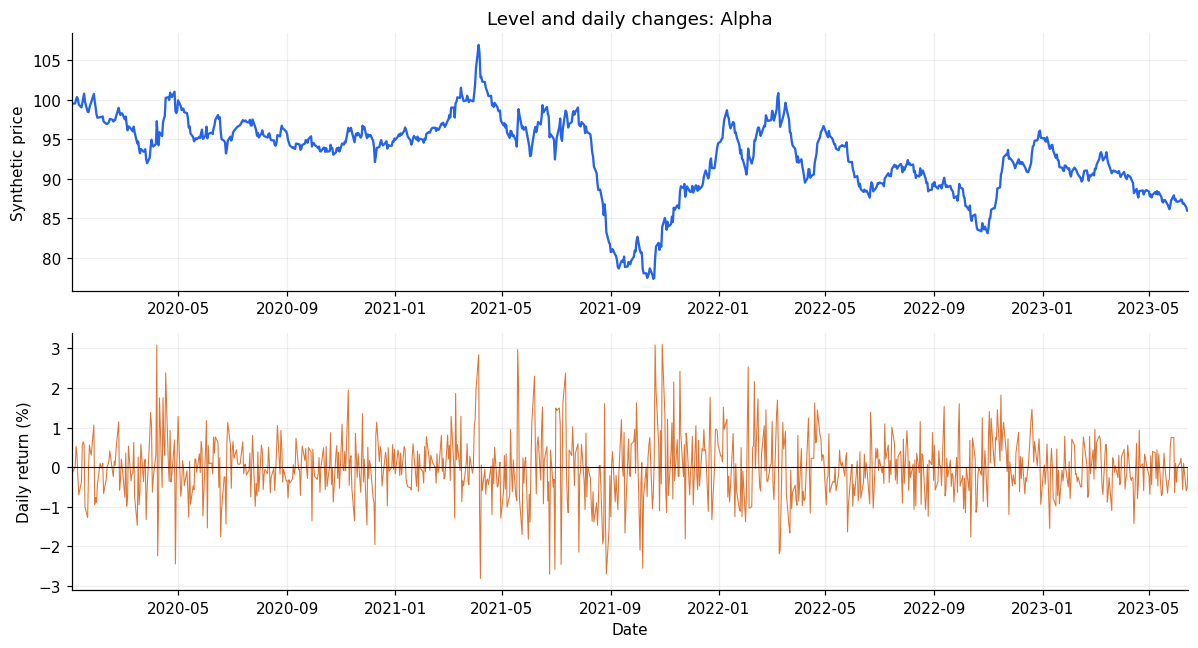

In [15]:
v01_asset = "Alpha"
# 每个模板新建 figure；subplot 选中后，后面的 plt.* 都画在当前子图上。
plt.figure(figsize=(11, 6))
time_limits = (min(wide_price.index.min(), wide_ret.index.min()),
               max(wide_price.index.max(), wide_ret.index.max()))
plt.subplot(2, 1, 1)
plt.plot(wide_price.index, wide_price[v01_asset], color=COLORS[0])
plt.title("Level and daily changes: " + v01_asset)
plt.ylabel("Synthetic price")
plt.xlim(*time_limits)
plt.subplot(2, 1, 2)
plt.plot(wide_ret.index, wide_ret[v01_asset] * 100, color=COLORS[1], linewidth=0.7)
plt.axhline(0, color="black", linewidth=0.7)
plt.ylabel("Daily return (%)")
plt.xlabel("Date")
plt.xlim(*time_limits)
plt.tight_layout()
plt.show()

**如何读结果：** 上图帮助看长期路径；下图帮助定位大变化与波动簇。相同的水平变化，在不同价格基数上可能对应不同的百分比变化。

**常见误判：** 两个共同上升的水平序列容易有很高相关，这并不意味着收益相关、可预测或有因果关系。非正值序列可能不适合百分比变化。

<a id='V02'></a>
## V02 · 归一化小图：比较多对象而不遮挡

**何时使用：** 对象初始规模不同、折线堆叠难以辨认。

**想回答的问题：** 从共同起点开始，谁的相对路径、波动形状或缺口不同？

**输入要求：** wide_price，所有序列在选定共同起点均有正值；需要共同时间窗口。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

本图展示对象: ['Alpha', 'Beta', 'Delta', 'Gamma'] | 未展示对象数: 0


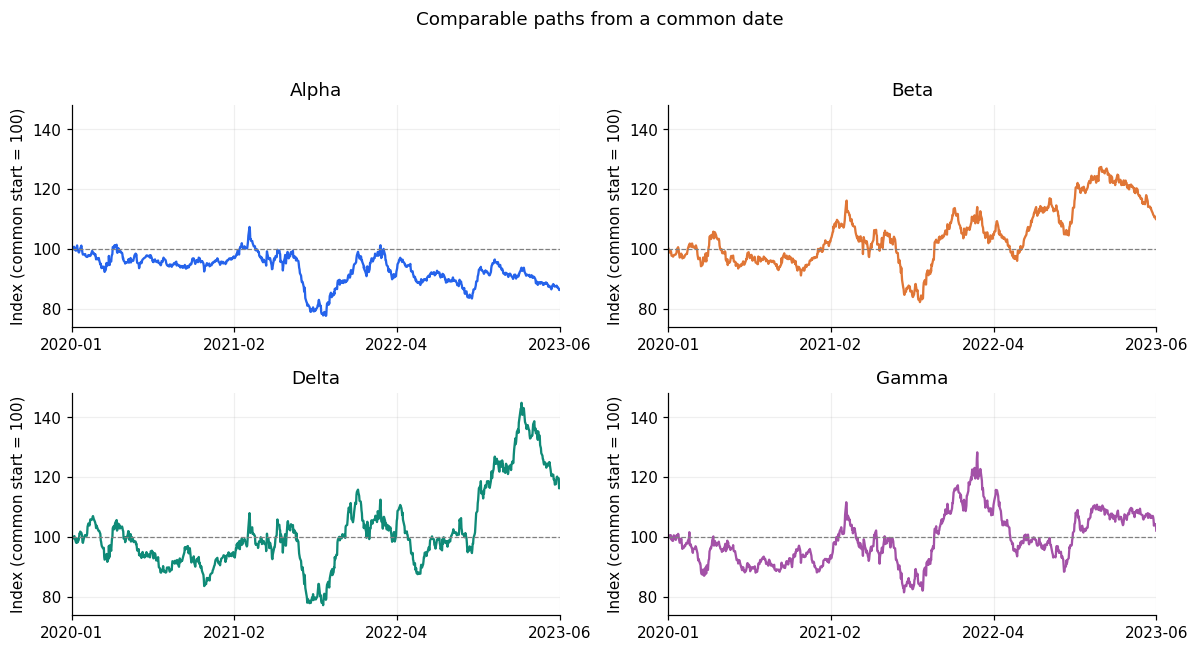

In [16]:
# 明确选择展示子集；对象多时绝不无声截断。可改为有依据的指定 ID 列表。
SELECTED_ASSETS = list(wide_price.columns[:6])
print("本图展示对象:", SELECTED_ASSETS, "| 未展示对象数:", len(wide_price.columns) - len(SELECTED_ASSETS))
v02 = wide_price[SELECTED_ASSETS].copy()
common_rows = v02.dropna(how="any")
if common_rows.empty:
    raise ValueError("所选对象不存在共同非缺失起点；先重新确定比较区间。")
common_start = common_rows.index[0]
if not v02.loc[common_start].gt(0).all():
    raise ValueError("相对价格归一化需要正的起点；其他变量选择差值图。")
rebased = v02.loc[common_start:].div(v02.loc[common_start]).mul(100)
ncols = min(2, len(SELECTED_ASSETS))
nrows = int(np.ceil(len(SELECTED_ASSETS) / ncols))
# 所有子图显式使用同样的横轴、纵轴范围，避免独立缩放误导比较。
y_min, y_max = rebased.min().min(), rebased.max().max()
y_padding = max((y_max - y_min) * 0.05, 1.0)
# 小图只显示少量日期标签，避免横轴文字重叠。
time_ticks = rebased.index[np.linspace(0, len(rebased) - 1, 4).astype(int)]
plt.figure(figsize=(11, min(7, 3*nrows)))
for i, asset in enumerate(SELECTED_ASSETS):
    plt.subplot(nrows, ncols, i + 1)
    plt.plot(rebased.index, rebased[asset], color=COLORS[i % len(COLORS)])
    plt.axhline(100, color="grey", linewidth=0.8, linestyle="--")
    plt.title(asset)
    plt.ylabel("Index (common start = 100)")
    plt.xlim(rebased.index.min(), rebased.index.max())
    plt.xticks(time_ticks, time_ticks.strftime("%Y-%m"))
    plt.ylim(y_min - y_padding, y_max + y_padding)
# 对象数为奇数时，不创建多余的空子图。
plt.suptitle("Comparable paths from a common date")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**如何读结果：** 相同 y 轴使波动幅度可比较；每个对象一格减少遮挡。100 表示共同起点，150 表示相对该起点累计增加 50%。

**常见误判：** 各自第一个有效日期归一化会比较不同区间；共同起点可能丢掉很多早期历史，应报告选择。归一化不会消除币种、杠杆或风险差异。

<a id='V03'></a>
## V03 · 缺失热图：检查成片缺口和同步故障

**何时使用：** 多对象面板存在空白、断档或字段缺失。

**想回答的问题：** 缺失集中于某一对象、某段时间，还是所有对象同步发生？

**输入要求：** dirty_panel，先隔离重复键，再重建预期日期×对象网格。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

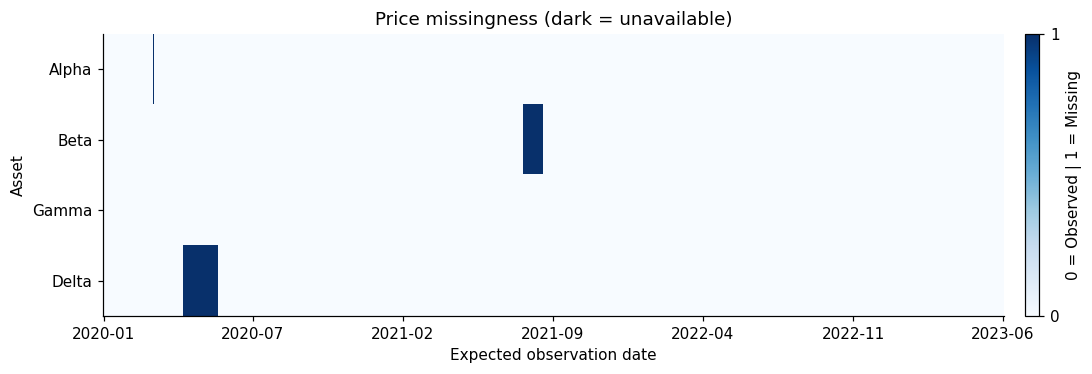

In [17]:
v03 = dirty_panel.drop_duplicates().copy()
v03 = v03.loc[~v03.duplicated(["date", "asset"], keep=False)]
p = v03.pivot(index="date", columns="asset", values="price").reindex(index=dates, columns=assets)
missing = p.isna().T
plt.figure(figsize=(11, 3.5))
plt.imshow(missing.values, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
plt.yticks(np.arange(len(assets)), assets)
ticks = np.linspace(0, len(dates)-1, 7).astype(int)
plt.xticks(ticks, dates[ticks].strftime("%Y-%m"))
plt.title("Price missingness (dark = unavailable)")
plt.xlabel("Expected observation date")
plt.ylabel("Asset")
plt.grid(False)
plt.colorbar(ticks=[0, 1], pad=0.02, label="0 = Observed | 1 = Missing")
plt.tight_layout()
plt.show()

**如何读结果：** Beta 的深色段来自有行但无价格；Delta 的深色段来自缺整行。图用于定位，D04 的表用于解释缺失类别。单个像素缺失在长历史里可能不明显，因此图表应搭配计数。

**常见误判：** 如果只对原始已出现的行画 isna，完全缺掉的日期不会显示。错误数值如负价不会被这张缺失图识别，需要单独质量检查。

<a id='V04'></a>
## V04 · 覆盖率与缺口长度：判断数据是否可比

**何时使用：** 决定哪些对象适合一起比较，或检查月度采集稳定性。

**想回答的问题：** 谁的覆盖率低？缺口是零散一天还是连续很长？

**输入要求：** dirty_panel 与预期 dates；对象在本例全程应存在。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

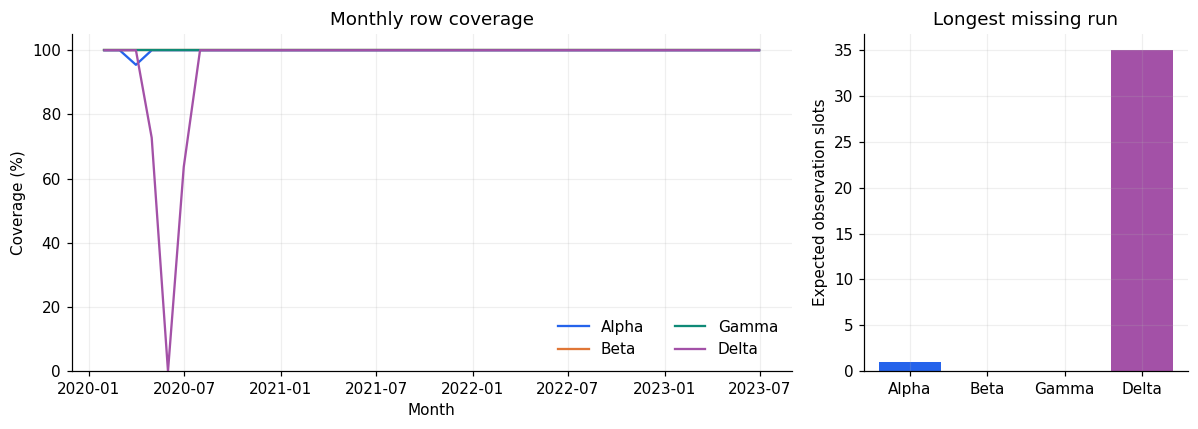

,longest_missing_run
Alpha,1
Beta,0
Gamma,0
Delta,35


In [18]:
v04 = dirty_panel.drop_duplicates().copy()
v04 = v04.loc[~v04.duplicated(["date", "asset"], keep=False)]
present = v04.assign(present=1).pivot(index="date", columns="asset", values="present").reindex(index=dates, columns=assets).fillna(0)
monthly_coverage = present.resample(pd.offsets.MonthEnd()).mean() * 100
# 最长连续缺行段：按观测日历计数，而非自然日天数。
longest_gap = {}
for asset in assets:
    absent = present[asset].eq(0)
    runs = absent.groupby(absent.ne(absent.shift()).cumsum()).sum()
    longest_gap[asset] = int(runs.max())
plt.figure(figsize=(11, 4))
# 1 行 3 列网格：左图占 2 列，右图占 1 列。
plt.subplot2grid((1, 3), (0, 0), colspan=2)
for i, asset in enumerate(assets):
    plt.plot(monthly_coverage.index, monthly_coverage[asset], label=asset, color=COLORS[i % len(COLORS)])
plt.title("Monthly row coverage")
plt.ylabel("Coverage (%)")
plt.xlabel("Month")
plt.ylim(0, 105)
plt.legend(ncol=2)
plt.subplot2grid((1, 3), (0, 2))
plt.bar(list(longest_gap), list(longest_gap.values()), color=[COLORS[i % len(COLORS)] for i in range(len(longest_gap))])
plt.title("Longest missing run")
plt.ylabel("Expected observation slots")
plt.tight_layout()
plt.show()
display(pd.Series(longest_gap, name="longest_missing_run").to_frame())

**如何读结果：** 长期总体覆盖率接近 100% 仍可能藏着严重的一段断档。右图补充连续缺口长度，适合判断滚动特征会有多久无法生成。

**常见误判：** 这张图统计行是否存在，字段为空仍算有行；覆盖率分母要考虑上市/激活日期和节假日，不能机械要求所有对象覆盖整个历史。

<a id='V05'></a>
## V05 · 直方图 + ECDF + 尾部分位数

**何时使用：** 检查分布偏斜、极端值和普通正态近似是否合适。

**想回答的问题：** 大多数变化集中在哪里？左右尾部有多长？超过某阈值的频率是多少？

**输入要求：** 一条收益/误差/增量序列；多对象比较时应保证单位一致。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

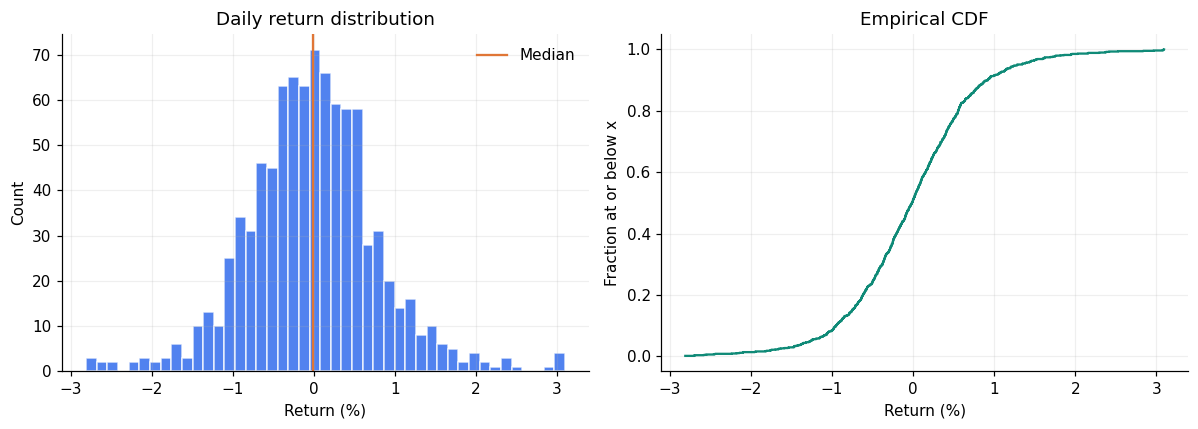

,return_percent
0.001,-2.710729
0.010,-2.143982
0.050,-1.254661
0.500,-0.014413
0.950,1.281834
0.990,2.297518
0.999,3.083586


样本数: 899 | 绝对变化 > 3% 的经验比例: 0.0033


In [19]:
v05 = wide_ret["Alpha"].dropna() * 100
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.hist(v05, bins=45, color=COLORS[0], alpha=0.8, edgecolor="white")
plt.axvline(v05.median(), color=COLORS[1], label="Median")
plt.title("Daily return distribution")
plt.xlabel("Return (%)")
plt.ylabel("Count")
plt.legend()
x = np.sort(v05.values)
y = np.arange(1, len(x)+1) / len(x)
plt.subplot(1, 2, 2)
plt.step(x, y, where="post", color=COLORS[2])
plt.title("Empirical CDF")
plt.xlabel("Return (%)")
plt.ylabel("Fraction at or below x")
plt.tight_layout()
plt.show()
quantiles = v05.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
display(quantiles.rename("return_percent").to_frame())
print("样本数:", len(v05), "| 绝对变化 > 3% 的经验比例:", round(v05.abs().gt(3).mean(), 4))

**如何读结果：** ECDF 在 x 处的高度就是样本中不超过 x 的比例，不依赖直方图分箱。分位数表提供尾部的具体数值；0.1% 尾部在不足千条样本中只由极少观测决定。

**常见误判：** 平滑直方图不证明正态；独立性和时间稳定性也不能从边际分布判断。样本极端分位数不等于可靠的未来风险界限。

<a id='V06'></a>
## V06 · 在时间轴上标记异常，不自动删除

**何时使用：** 发现极值，想核对对应日期、是否连续发生以及是否属于真实阶段。

**想回答的问题：** 哪些日期超过训练期阈值？极值是否集中在特定时段？

**输入要求：** wide_ret 与 train_cutoff；阈值在训练期固定后应用于全时期。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

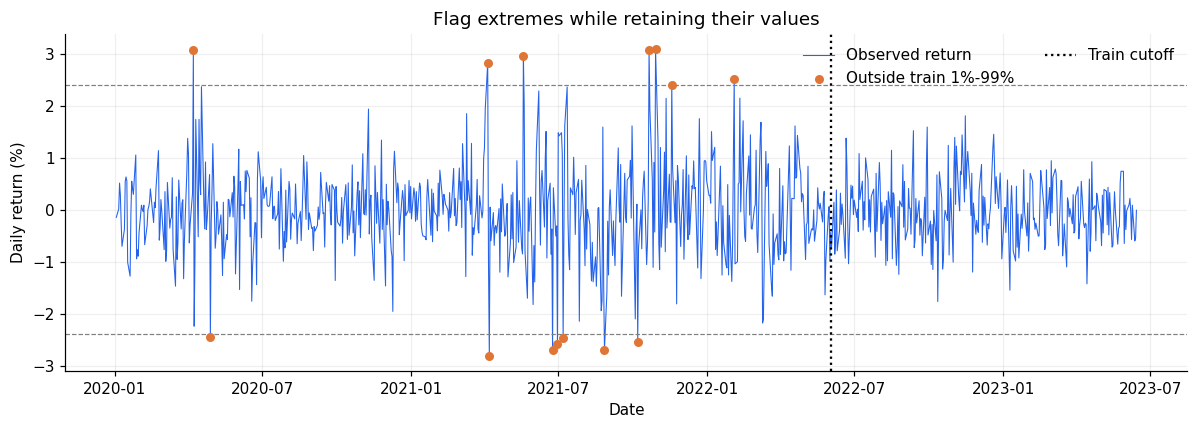

,flagged_return
date,
2021-10-29,0.030957
2021-10-21,0.030822
2020-04-07,0.030793
2021-05-19,0.029665
2021-04-05,0.028375
2021-04-07,-0.028102
2021-06-24,-0.026994
2021-08-27,-0.026947


In [20]:
v06 = wide_ret["Alpha"]
train = v06.loc[v06.index < train_cutoff].dropna()
lo, hi = train.quantile([0.01, 0.99])
flag = v06.lt(lo) | v06.gt(hi)
plt.figure(figsize=(11, 4))
plt.plot(v06.index, v06 * 100, color=COLORS[0], linewidth=0.7, label="Observed return")
plt.scatter(v06.index[flag], v06.loc[flag] * 100, color=COLORS[1], s=24, label="Outside train 1%-99%", zorder=3)
plt.axhline(lo * 100, color="grey", linestyle="--", linewidth=0.8)
plt.axhline(hi * 100, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(train_cutoff, color="black", linestyle=":", label="Train cutoff")
plt.title("Flag extremes while retaining their values")
plt.ylabel("Daily return (%)")
plt.xlabel("Date")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
display(v06.loc[flag].sort_values(key=np.abs, ascending=False).head(8).rename("flagged_return").to_frame())

**如何读结果：** 橙点只是需要解释的罕见观测。本例训练期包含一段高波动，阈值受其影响；换训练期会改变标记。极值聚集可以提示阶段变化或共因冲击。

**常见误判：** 这不是显著性检验，也不是记录错误判定器。删除真实坏日会美化策略。若修正记录错误，必须留下来源依据与修改日志。

<a id='V07'></a>
## V07 · 滚动均值与波动：观察非平稳性

**何时使用：** 总体平均掩盖时间变化，或怀疑风险在不同阶段不同。

**想回答的问题：** 局部平均和波动是否稳定？何时发生持续变化？

**输入要求：** wide_ret，至少有窗口长度的有效观测。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

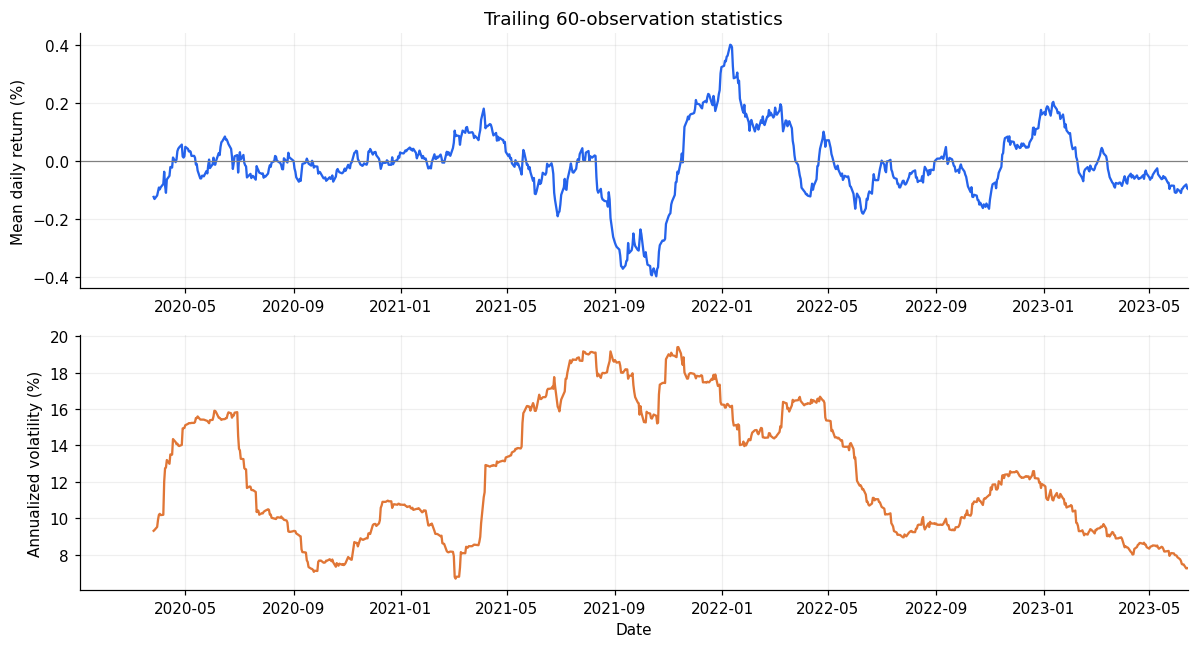

In [21]:
v07 = wide_ret["Alpha"]
window = 60
rolling_mean = v07.rolling(window, min_periods=window).mean()
rolling_vol = v07.rolling(window, min_periods=window).std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
plt.figure(figsize=(11, 6))
plt.subplot(2, 1, 1)
plt.plot(v07.index, rolling_mean * 100, color=COLORS[0])
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Trailing 60-observation statistics")
plt.ylabel("Mean daily return (%)")
plt.xlim(v07.index.min(), v07.index.max())
plt.subplot(2, 1, 2)
plt.plot(v07.index, rolling_vol * 100, color=COLORS[1])
plt.ylabel("Annualized volatility (%)")
plt.xlabel("Date")
plt.xlim(v07.index.min(), v07.index.max())
plt.tight_layout()
plt.show()

**如何读结果：** 滚动图展示历史窗口的变化，窗口越长越平滑但反应越慢。年化波动此处使用 sqrt(252) 的常见尺度换算；它依赖日频且隐含简化假设。

**常见误判：** 相邻窗口高度重叠，不能把连续 20 个高点当作 20 次独立证据。年化滚动均值不是已实现年度收益，窗口末端统计也不能拿去预测窗口开头。

<a id='V08'></a>
## V08 · 滚动相关：总体关系会不会变化

**何时使用：** 两个序列总体相关不高，或总体相关掩盖某段共同变化。

**想回答的问题：** 收益之间的同期关系是否随时间改变？有效样本数是否足够？

**输入要求：** 两个按时间对齐、同频同口径的变化序列。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

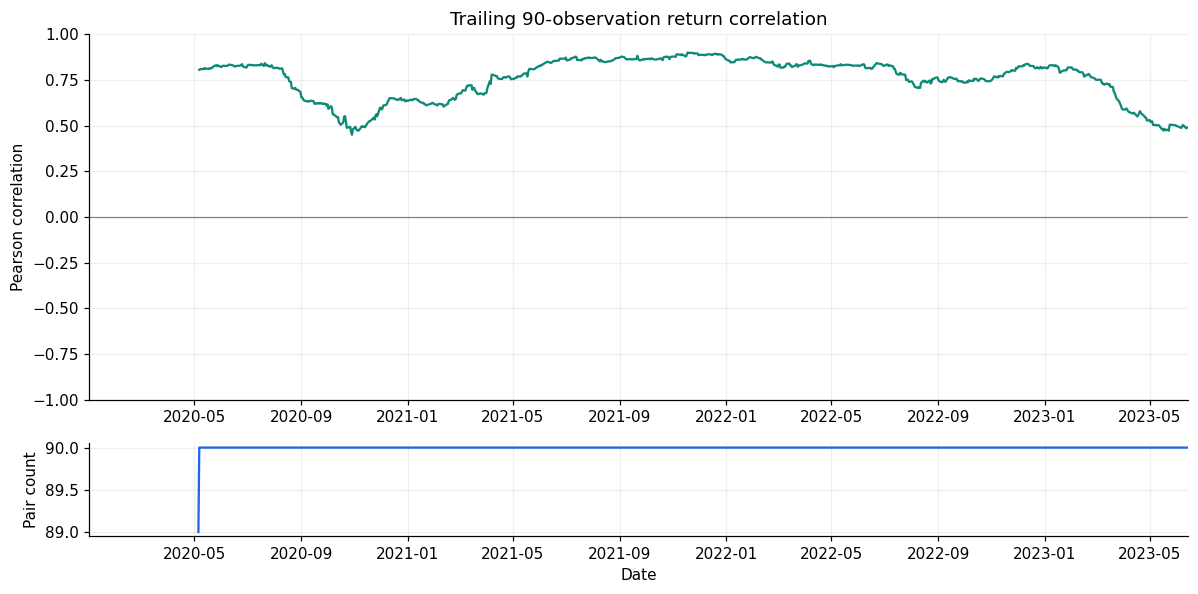

In [22]:
pair = wide_ret[["Alpha", "Beta"]].copy()
window = 90
valid_pair = pair.notna().all(axis=1)
rolling_n = valid_pair.astype(int).rolling(window, min_periods=window).sum()
rolling_corr = pair["Alpha"].rolling(window, min_periods=window).corr(pair["Beta"])
plt.figure(figsize=(11, 5.5))
# 上图占 3 行、下图占 1 行；两图设置同样的时间范围。
plt.subplot2grid((4, 1), (0, 0), rowspan=3)
plt.plot(pair.index, rolling_corr, color=COLORS[2])
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Trailing 90-observation return correlation")
plt.ylabel("Pearson correlation")
plt.ylim(-1, 1)
plt.xlim(pair.index.min(), pair.index.max())
plt.subplot2grid((4, 1), (3, 0))
plt.plot(pair.index, rolling_n, color=COLORS[0])
plt.ylabel("Pair count")
plt.xlabel("Date")
plt.xlim(pair.index.min(), pair.index.max())
plt.tight_layout()
plt.show()

**如何读结果：** 上图是窗口内的同期相关；下图保证看得见有效样本量。相关变化可能来自共同因子强度、特异波动或样本构成变化。

**常见误判：** 同期相关不能直接形成预测。短窗口相关很不稳定，长窗口又有滞后；发现一段高相关后专门选择窗口长度，会带来选择偏差。

<a id='V09'></a>
## V09 · 相关矩阵旁边必须有共同样本数

**何时使用：** 多变量探索、冗余特征检查、资产共同波动初筛。

**想回答的问题：** 哪些变化序列共同移动？相关值是否基于同样数量的观测？

**输入要求：** 宽表 wide_ret；本例额外放入缺失，以显示 pairwise 删除的差异。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

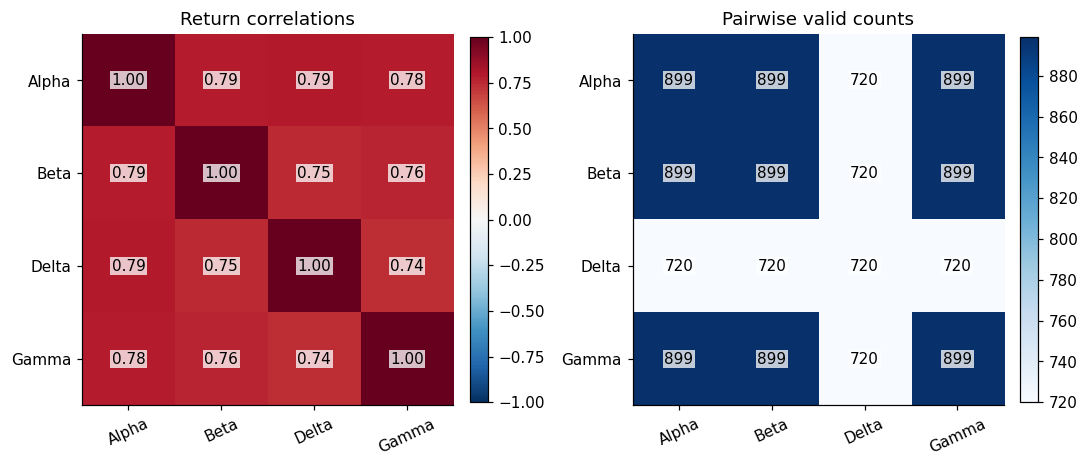

In [23]:
v09 = wide_ret.copy()
v09.loc[dates[:180], "Delta"] = np.nan
corr = v09.corr(min_periods=200)
valid = v09.notna().astype(int)
pair_n = valid.T.dot(valid)
plt.figure(figsize=(10, 4.5))
for panel_number, matrix, title, fmt in [(1, corr, "Return correlations", ".2f"), (2, pair_n, "Pairwise valid counts", ".0f")]:
    plt.subplot(1, 2, panel_number)
    if panel_number == 1:
        plt.imshow(matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
    else:
        plt.imshow(matrix.values, cmap="Blues")
    plt.xticks(np.arange(len(matrix.columns)), matrix.columns, rotation=25)
    plt.yticks(np.arange(len(matrix.index)), matrix.index)
    plt.title(title)
    plt.grid(False)
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            val = matrix.iloc[i, j]
            label = format(val, fmt) if pd.notna(val) else "NA"
            plt.text(j, i, label, ha="center", va="center", fontsize=10,
                     bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 1})
    # 当前子图刚画完热图，colorbar 会对应这张热图。
    plt.colorbar(fraction=0.045, pad=0.04)
plt.tight_layout()
plt.show()

**如何读结果：** 左边报告线性同期关系，右边显示每对变量究竟用了多少共同日期。Delta 的相关样本期不同，因此其数值可能同时受样本阶段影响。

**常见误判：** pairwise 相关矩阵可能不是半正定矩阵，不宜未经处理直接用于优化。要严谨比较，可额外在全体共同日期上重算，并报告损失的样本量。

<a id='V10'></a>
## V10 · 滞后散点：检验关系方向和极值影响

**何时使用：** 研究一个当前/历史特征是否与下一期目标有关。

**想回答的问题：** x_t 与 y_(t+1) 的关系是否线性、单调，是否由几个点驱动？

**输入要求：** 同一资产的日收益；在 t 收盘后定义 x_t = r_t，目标 = 下一期收益。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

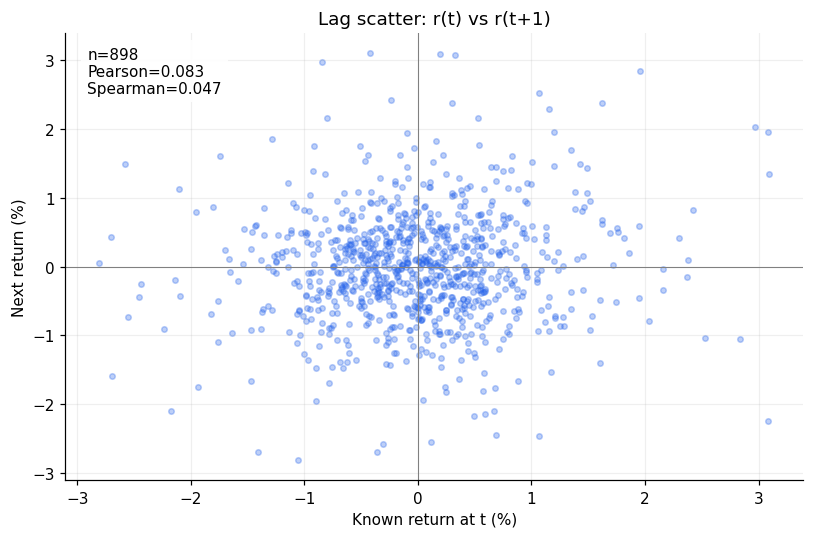

In [24]:
v10 = pd.DataFrame({"x_t": wide_ret["Alpha"], "y_next": wide_ret["Alpha"].shift(-1)}).dropna()
# 同一共同样本计算 Pearson 与 Spearman；rank().corr() 不需要 scipy。
pearson = v10["x_t"].corr(v10["y_next"])
spearman = v10["x_t"].rank(method="average").corr(v10["y_next"].rank(method="average"))
plt.figure(figsize=(7.5, 5))
plt.scatter(v10["x_t"] * 100, v10["y_next"] * 100, s=13, alpha=0.3, color=COLORS[0])
plt.axhline(0, color="grey", linewidth=0.7)
plt.axvline(0, color="grey", linewidth=0.7)
plt.title("Lag scatter: r(t) vs r(t+1)")
plt.xlabel("Known return at t (%)")
plt.ylabel("Next return (%)")
# axes fraction 表示子图内部比例坐标，(0, 0) 在左下角，(1, 1) 在右上角。
plt.annotate("n={}\nPearson={:.3f}\nSpearman={:.3f}".format(len(v10), pearson, spearman),
             xy=(0.03, 0.97), xycoords="axes fraction", va="top",
             bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "none"})
plt.tight_layout()
plt.show()

**如何读结果：** Pearson 看线性关系，Spearman 看秩的单调关系。二者都弱时，散点仍能揭示异方差或极值。此图展示探索关系，不是经过独立测试的预测结果。

**常见误判：** 先 shift 后对齐，不能分别 dropna 后按位置拼接。一个相关系数不能证明稳定盈利；同时尝试很多 lag 后挑最好值，会高估发现。

<a id='V11'></a>
## V11 · ACF：变化与绝对变化的记忆可能不同

**何时使用：** 检查自相关、波动簇、可能的周期或需要怎样做验证。

**想回答的问题：** 过去的方向是否延续？过去的大幅度变化是否预示未来的大幅度变化？

**输入要求：** 规则观测网格上的日收益；本例无中间缺失，保留原时间索引。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

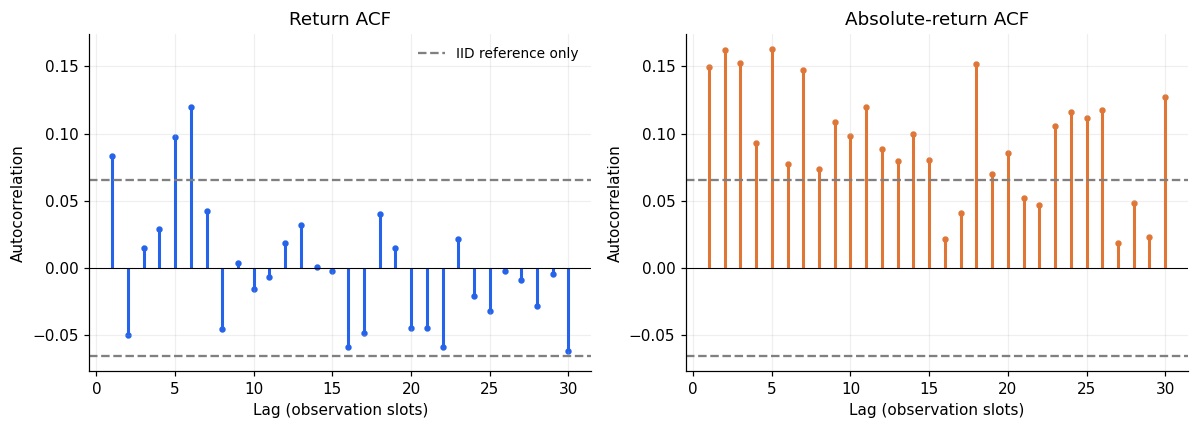

In [25]:
v11 = wide_ret["Alpha"].copy()
max_lag = 30
lags = np.arange(1, max_lag + 1)
acf_return = pd.Series([v11.autocorr(lag=int(k)) for k in lags], index=lags)
acf_abs = pd.Series([v11.abs().autocorr(lag=int(k)) for k in lags], index=lags)
# 仅作“白噪声独立近似”的参考线，不是异方差/重叠序列的可靠置信区间。
reference = 1.96 / np.sqrt(v11.notna().sum())
# 两图显式使用同样的纵轴范围，包含参考线与两组 ACF 的全部值。
acf_min = min(acf_return.min(), acf_abs.min(), -reference)
acf_max = max(acf_return.max(), acf_abs.max(), reference)
acf_padding = max((acf_max - acf_min) * 0.05, 0.01)
plt.figure(figsize=(11, 4))
for panel_number, values, title, color in [(1, acf_return, "Return ACF", COLORS[0]), (2, acf_abs, "Absolute-return ACF", COLORS[1])]:
    plt.subplot(1, 2, panel_number)
    plt.vlines(lags, 0, values, color=color, linewidth=2)
    plt.scatter(lags, values, color=color, s=10)
    plt.axhline(0, color="black", linewidth=0.7)
    plt.axhline(reference, color="grey", linestyle="--", label="IID reference only")
    plt.axhline(-reference, color="grey", linestyle="--")
    plt.title(title)
    plt.xlabel("Lag (observation slots)")
    plt.ylabel("Autocorrelation")
    plt.ylim(acf_min - acf_padding, acf_max + acf_padding)
    if panel_number == 1:
        plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**如何读结果：** 收益方向的自相关可以很弱，而绝对收益呈现更明显的持续性；这正是波动簇可能出现的形状。横轴是观测格数，不是自然日。

**常见误判：** 虚线不是在所有场景有效的显著性界限，也没有调整 30 个 lag 的多重比较。不要 dropna 后压缩日历再声称是固定日历 lag；非平稳水平可能产生虚假的高自相关。

<a id='V12'></a>
## V12 · 星期与小时箱线图：看季节性和样本不均衡

**何时使用：** 怀疑每周某天、每天某小时存在系统差异。

**想回答的问题：** 各时间组的中位数、分散度与样本量是否不同？

**输入要求：** 日频收益用于星期；events 的 event-level value 用于小时。确认本地时间和采集方式。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

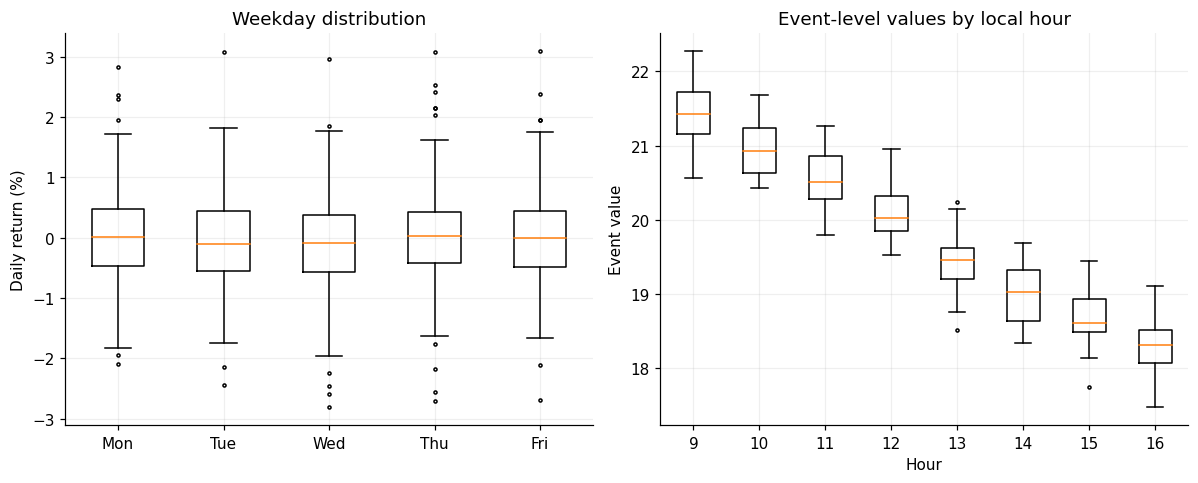

,weekday,n
0,Mon,180
1,Tue,180
2,Wed,180
3,Thu,179
4,Fri,180


,hour,event_n
0,9,66
1,10,19
2,11,29
3,12,27
4,13,25
5,14,20
6,15,22
7,16,91


In [26]:
v12_daily = wide_ret["Alpha"].dropna()
weekday_groups = [v12_daily.loc[v12_daily.index.dayofweek == k] * 100 for k in range(5)]
hours = np.arange(9, 17)
hour_groups = [events.loc[events["timestamp"].dt.hour.eq(h), "value"] for h in hours]
plt.figure(figsize=(11, 4.5))
plt.subplot(1, 2, 1)
plt.boxplot(weekday_groups, showfliers=True, flierprops={"markersize": 2})
# 单独设置刻度，避免不同 Matplotlib 版本 labels / tick_labels 参数变化。
plt.xticks(np.arange(1, 6), ["Mon", "Tue", "Wed", "Thu", "Fri"])
plt.title("Weekday distribution")
plt.ylabel("Daily return (%)")
plt.subplot(1, 2, 2)
plt.boxplot(hour_groups, showfliers=True, flierprops={"markersize": 2})
plt.xticks(np.arange(1, len(hours) + 1), [str(h) for h in hours])
plt.title("Event-level values by local hour")
plt.ylabel("Event value")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"weekday": ["Mon", "Tue", "Wed", "Thu", "Fri"], "n": [len(x) for x in weekday_groups]}))
display(pd.DataFrame({"hour": hours, "event_n": [len(x) for x in hour_groups]}))

**如何读结果：** 箱体通常表示 25%–75% 分位，中线表示中位数，离群点是箱线图规则标记。小时图是事件加权的分布：某些日期/小时事件多，权重更大。

**常见误判：** 肉眼差别不是稳定日历效应；本例只有少量事件日期。要比较典型一天的小时模式，先按 day/hour 汇总，再跨天比较，并在独立时期验证。

<a id='V13'></a>
## V13 · 年 × 月收益热图：展示阶段一致性

**何时使用：** 需要快速看到月度收益的好坏年份、季节性候选和缺失月份。

**想回答的问题：** 效果是否集中在某些月份？哪些格子其实没有完整数据？

**输入要求：** 日收益 wide_ret 与完整模拟月工作日历；不完整月不显示收益。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

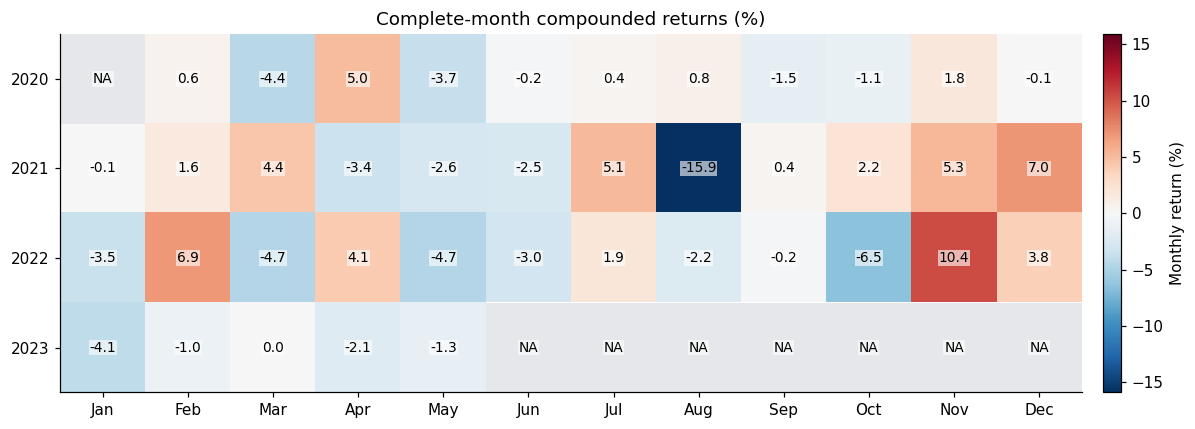

month,1,2,3,4,5,6,7,8,9,10,11,12
valid_daily_return_count,,,,,,,,,,,,
2020,21.0,20.0,22.0,22.0,21.0,22.0,23.0,21.0,22.0,22.0,21.0,23.0
2021,21.0,20.0,23.0,22.0,21.0,22.0,22.0,22.0,22.0,21.0,22.0,23.0
2022,21.0,20.0,23.0,21.0,22.0,22.0,21.0,23.0,22.0,21.0,22.0,22.0
2023,22.0,20.0,23.0,20.0,23.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
v13 = wide_ret["Alpha"]
rule = pd.offsets.MonthEnd()
mret = v13.resample(rule).apply(lambda s: (1+s).prod(min_count=1)-1)
count = v13.resample(rule).count()
calendar = pd.bdate_range(v13.index.min().to_period("M").start_time, v13.index.max().to_period("M").end_time.normalize())
expected = pd.Series(1, index=calendar).resample(rule).sum()
mret = mret.where(count.eq(expected))
frame = pd.DataFrame({"year": mret.index.year, "month": mret.index.month, "ret": mret.values, "n": count.values})
years = sorted(frame["year"].unique())
matrix = frame.pivot(index="year", columns="month", values="ret").reindex(index=years, columns=range(1, 13)) * 100
counts = frame.pivot(index="year", columns="month", values="n").reindex(index=years, columns=range(1, 13))
limit = max(1, np.nanmax(np.abs(matrix.values)))
plt.figure(figsize=(11, 4))
plt.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
plt.xticks(np.arange(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(np.arange(len(years)), years)
plt.title("Complete-month compounded returns (%)")
plt.grid(False)
for i in range(len(years)):
    for j in range(12):
        value = matrix.iloc[i, j]
        if pd.isna(value):
            # 给无有效月收益的格子涂灰；缺失既不是 0，也不参与颜色尺度。
            plt.fill_between([j - 0.5, j + 0.5], i - 0.5, i + 0.5, color="#e5e7eb", linewidth=0)
        plt.text(j, i, "{:.1f}".format(value) if pd.notna(value) else "NA", ha="center", va="center", fontsize=9,
                 bbox={"facecolor": "white", "alpha": 0.6, "edgecolor": "none", "pad": 0.5})
plt.colorbar(label="Monthly return (%)", fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()
display(counts.rename_axis("valid_daily_return_count"))

**如何读结果：** 蓝/红分别表示负/正月收益，色阶围绕 0 对称；灰色 NA 表示缺失或不完整，绝不等于 0。下方计数帮助检查数据完整性。

**常见误判：** 本例使用模拟工作日日历；真实市场必须换交易日历。只有三四年历史时，每个日历月的重复次数很少，不能据颜色宣布稳定季节性。

<a id='V14'></a>
## V14 · 量价关系优先用共享时间轴分图

**何时使用：** 两个变量单位不同，同时观察是否有共同事件。

**想回答的问题：** 大变化发生时数量是否放大？数量趋势是否独立于水平趋势？

**输入要求：** demo_panel 单一对象的价格、收益和数量。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

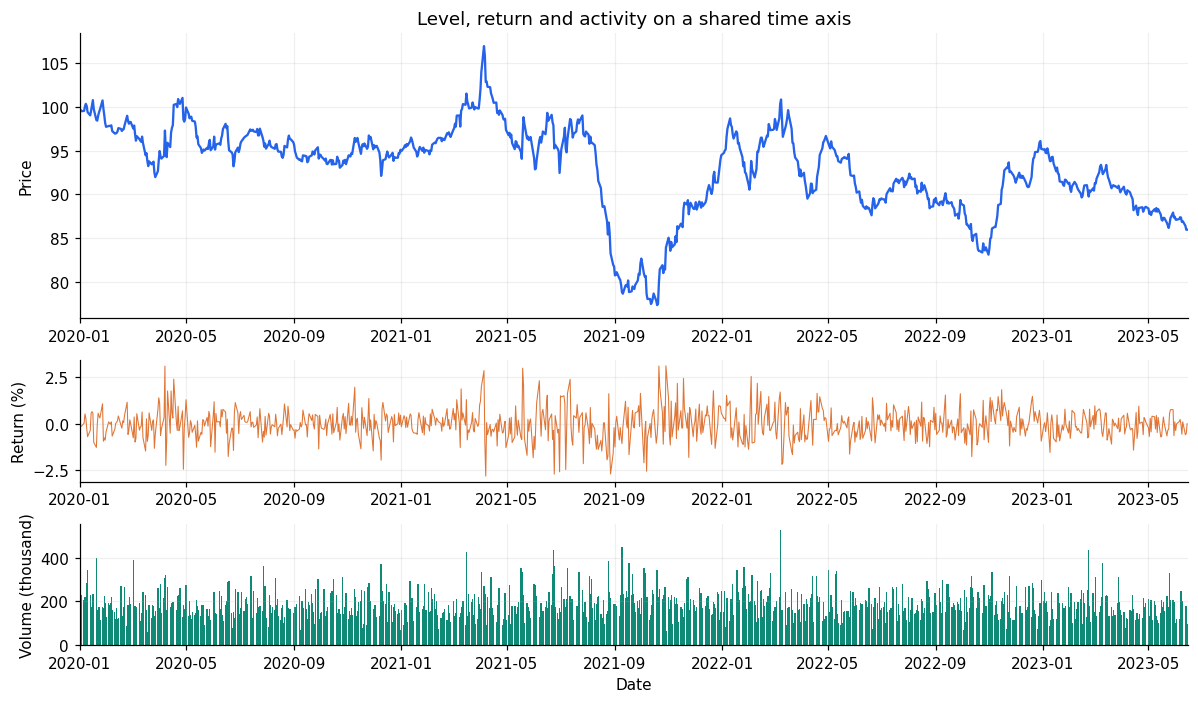

In [28]:
v14 = demo_panel.loc[demo_panel["asset"].eq("Alpha")].set_index("date")
# 两端留出柱子宽度，三个子图仍使用相同时间范围。
time_limits = (v14.index.min() - pd.Timedelta(days=1),
               v14.index.max() + pd.Timedelta(days=1))
plt.figure(figsize=(11, 6.5))
# 4 行网格中，上图占 2 行，其余各占 1 行。
plt.subplot2grid((4, 1), (0, 0), rowspan=2)
plt.plot(v14.index, v14["price"], color=COLORS[0])
plt.title("Level, return and activity on a shared time axis")
plt.ylabel("Price")
plt.xlim(*time_limits)
plt.subplot2grid((4, 1), (2, 0))
plt.plot(v14.index, v14["ret"] * 100, color=COLORS[1], linewidth=0.7)
plt.ylabel("Return (%)")
plt.xlim(*time_limits)
plt.subplot2grid((4, 1), (3, 0))
plt.bar(v14.index, v14["volume"] / 1000, color=COLORS[2], width=1.5)
plt.ylabel("Volume (thousand)")
plt.xlabel("Date")
plt.xlim(*time_limits)
plt.tight_layout()
plt.show()

**如何读结果：** 共享横轴可以定位同一天的共同异常，又不会让任意双轴缩放制造视觉重合。下方数量单位是千，便于读数。

**常见误判：** 量价同期关系不代表成交量可以预测未来；全天数量只有收盘后才完整。本例数量在生成时就与绝对收益有关，图中关系不是市场发现。

<a id='V15'></a>
## V15 · 阶段背景与训练/测试切分：把评估范围画出来

**何时使用：** 解释非平稳数据，汇报哪些时期用于发现和哪些用于评估。

**想回答的问题：** 切分点附近是否伴随分布变化？某个效果是否只在已知阶段出现？

**输入要求：** wide_ret + demo_panel.regime；阶段标记只因仿真才已知，不用于预测。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

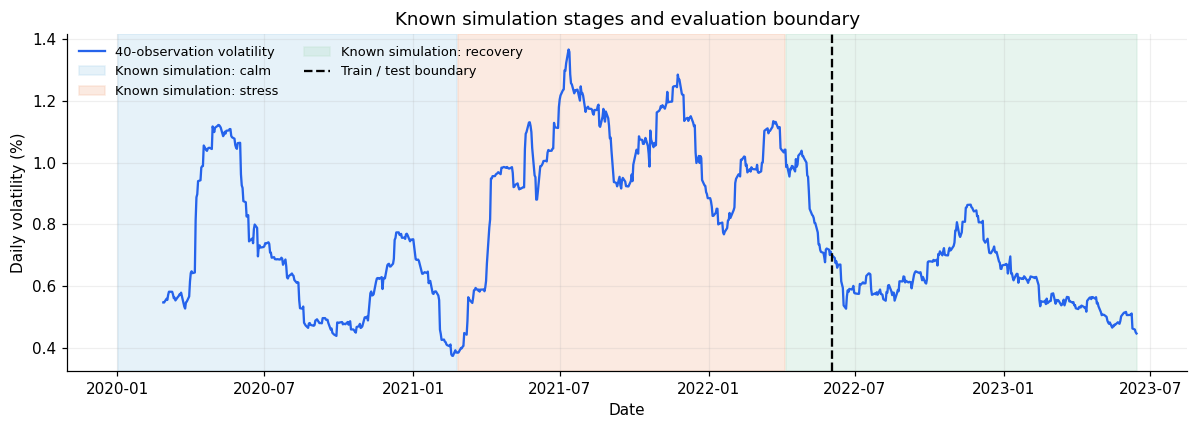

In [29]:
v15 = wide_ret["Alpha"]
phase_series = demo_panel.loc[demo_panel["asset"].eq("Alpha")].set_index("date")["regime"]
plt.figure(figsize=(11, 4))
plt.plot(v15.index, v15.rolling(40, min_periods=40).std() * 100, color=COLORS[0], label="40-observation volatility")
phase_colors = {"calm": "#b8dbef", "stress": "#f5c4a9", "recovery": "#bde1cf"}
for name in ["calm", "stress", "recovery"]:
    idx = phase_series.index[phase_series.eq(name)]
    plt.axvspan(idx.min(), idx.max(), color=phase_colors[name], alpha=0.35, label="Known simulation: " + name)
plt.axvline(train_cutoff, color="black", linestyle="--", label="Train / test boundary")
plt.title("Known simulation stages and evaluation boundary")
plt.ylabel("Daily volatility (%)")
plt.xlabel("Date")
plt.legend(ncol=2, fontsize=8.5)
plt.tight_layout()
plt.show()

**如何读结果：** 背景说明生成机制和评估区间的关系。测试阶段可能与训练阶段不同，这正是模型需要面对的分布变化。

**常见误判：** 真实阶段通常不能事先完美辨认，事后划分好/坏时期不能直接当作交易规则。不能为了提高测试结果而反复移动切分点。

<a id='V16'></a>
## V16 · 训练期定分位边界，再比较未来目标

**何时使用：** 检查一个连续特征与未来收益是否呈单调关系，或模型分数是否有区分力。

**想回答的问题：** 高特征组和低特征组的未来均值有何差异？测试期是否延续？每组有多少样本？

**输入要求：** 单资产收盘后动量特征与下一日收益；分箱边界只由训练期学习。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

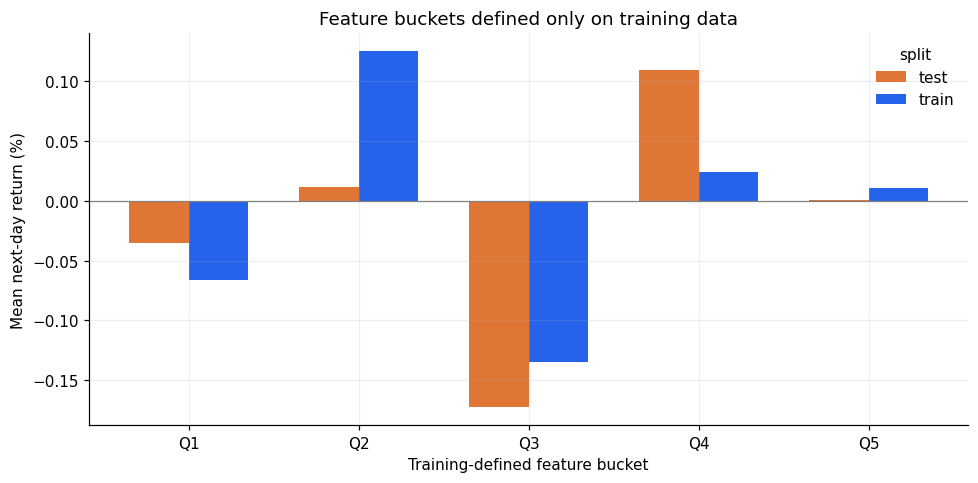

mean  count      std
split bucket                         
test  Q1     -0.00036     79  0.00630
      Q2      0.00011     72  0.00621
      Q3     -0.00173     43  0.00533
      Q4      0.00109     40  0.00544
      Q5      0.00000     35  0.00735
train Q1     -0.00066    122  0.00938
      Q2      0.00125    122  0.00899
      Q3     -0.00135    121  0.00627
      Q4      0.00024    122  0.00866
      Q5      0.00010    122  0.00995

train 最高组减最低组均值差: 7.65 bps
test 最高组减最低组均值差: 3.61 bps


In [30]:
p = wide_price["Alpha"]
v16 = pd.DataFrame({"feature": p.pct_change(20, fill_method=None), "target": wide_ret["Alpha"].shift(-1)}, index=p.index)
v16["label_end"] = pd.Series(v16.index, index=v16.index).shift(-1)
v16 = v16.dropna()
train_mask = (v16.index < train_cutoff) & v16["label_end"].lt(train_cutoff)
test_mask = v16.index >= train_cutoff
# 重复分位点会降低组数；先去重，保证分箱合法。
inner_edges = np.unique(v16.loc[train_mask, "feature"].quantile([0.2, 0.4, 0.6, 0.8]).values)
edges = np.r_[-np.inf, inner_edges, np.inf]
labels = ["Q{}".format(i+1) for i in range(len(edges)-1)]
v16["bucket"] = pd.cut(v16["feature"], bins=edges, labels=labels, include_lowest=True)
v16["split"] = np.where(train_mask, "train", np.where(test_mask, "test", "purged"))
summary = v16.loc[v16["split"].ne("purged")].groupby(["split", "bucket"], observed=False)["target"].agg(["mean", "count", "std"])
means = summary["mean"].unstack("split").reindex(labels) * 100
plt.figure(figsize=(9, 4.5))
# 每个 bucket 内并列画 train / test，手动安排柱子位置，不调用 DataFrame.plot。
positions = np.arange(len(labels))
bar_width = 0.35
plt.bar(positions - bar_width / 2, means["test"], width=bar_width, color=COLORS[1], label="test")
plt.bar(positions + bar_width / 2, means["train"], width=bar_width, color=COLORS[0], label="train")
plt.xticks(positions, labels)
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Feature buckets defined only on training data")
plt.xlabel("Training-defined feature bucket")
plt.ylabel("Mean next-day return (%)")
plt.legend(title="split")
plt.tight_layout()
plt.show()
display(summary.round(5))
for split in ["train", "test"]:
    s = summary.loc[split, "mean"]
    print(split, "最高组减最低组均值差:", round((s.iloc[-1] - s.iloc[0]) * 10000, 2), "bps")

**如何读结果：** 分组均值的顺序比单个最好柱子更有解释力；测试期各组数量可以不均衡，因为边界固定。最高组减最低组是条件均值差，只用于诊断特征关系。

**常见误判：** 这不是已回测的多空策略：不同组通常发生在不同日期，没有组合权重、资金占用和交易成本。不要用全样本定边界，也不要把普通独立标准误套在强相关或重叠目标上。

<a id='V17'></a>
## V17 · 累计路径与回撤：初始净值 1 必须进入峰值

**何时使用：** 描述历史路径风险，或检查一条已明确定义的收益序列。

**想回答的问题：** 最大历史跌幅是多少？是否还未恢复？第一天亏损有没有被漏掉？

**输入要求：** 一条连续、无中间缺失、含义明确的收益序列；此处只是合成资产路径，不是策略回测。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

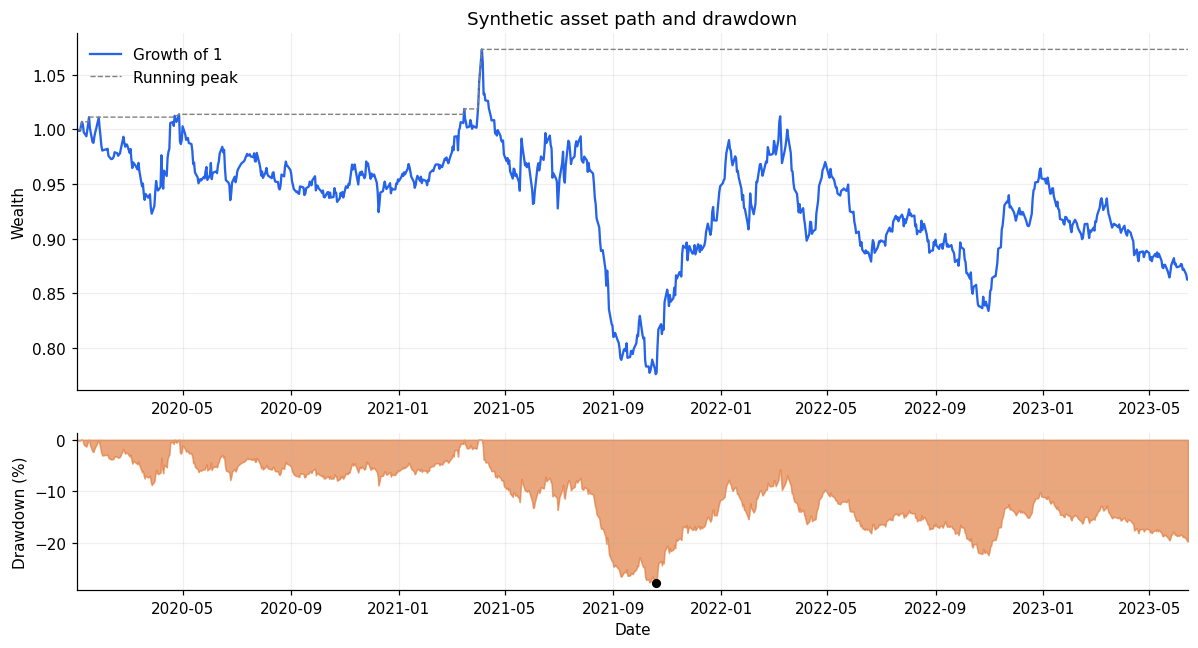

,max_drawdown,peak_date,trough_date,recovery_date
0,-0.277126,2021-04-05,2021-10-19,NaT


In [31]:
v17 = wide_ret["Alpha"].iloc[1:]  # 第一条本来就未知；仅去掉这条起始缺失。
if v17.isna().any():
    raise ValueError("中间收益缺失：先确定缺失语义，不把缺失当作零收益。")
if (v17 <= -1).any():
    raise ValueError("此净值模型要求收益 > -100%。")
# 添加初始净值，使第一段亏损也能被回撤正确捕捉。
initial_date = wide_ret.index[0]
wealth = pd.concat([pd.Series([1.0], index=[initial_date]), (1 + v17).cumprod()])
peak = wealth.cummax()
drawdown = wealth / peak - 1
trough_date = drawdown.idxmin()
peak_date = wealth.loc[:trough_date].idxmax()
recovered = wealth.loc[trough_date:].ge(wealth.loc[peak_date])
recovery_date = recovered.index[recovered][0] if recovered.any() else pd.NaT
plt.figure(figsize=(11, 6))
plt.subplot2grid((3, 1), (0, 0), rowspan=2)
plt.plot(wealth.index, wealth, color=COLORS[0], label="Growth of 1")
plt.plot(peak.index, peak, color="grey", linestyle="--", linewidth=0.9, label="Running peak")
plt.title("Synthetic asset path and drawdown")
plt.ylabel("Wealth")
plt.xlim(wealth.index.min(), wealth.index.max())
plt.legend()
plt.subplot2grid((3, 1), (2, 0))
plt.fill_between(drawdown.index, drawdown.values * 100, 0, color=COLORS[1], alpha=0.65)
plt.scatter([trough_date], [drawdown.loc[trough_date] * 100], color="black", s=25)
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.xlim(wealth.index.min(), wealth.index.max())
plt.tight_layout()
plt.show()
display(pd.DataFrame({"max_drawdown": [drawdown.min()], "peak_date": [peak_date], "trough_date": [trough_date], "recovery_date": [recovery_date]}))

**如何读结果：** 回撤是相对于历史最高净值的跌幅，最差点发生在谷底；恢复日期为空意味着样本结束时尚未恢复。净值从 1 开始，避免遗漏首段亏损。

**常见误判：** 样本最大回撤不是未来亏损上限。合成资产路径没有策略成本、杠杆、借券或滑点；多个资产不能简单平均各自回撤来代表组合回撤。

<a id='V18'></a>
## V18 · 不规则时间戳：间隔、事件计数与日内覆盖

**何时使用：** 事件日志、交易记录或传感器观测并非等间隔。

**想回答的问题：** 采集节奏是否变化？是否有很长的空窗？每小时统计用了多少事件？

**输入要求：** events，timestamp 可重复，但必须按业务定义判断是否应去重。

下面一格可在运行本 notebook 的 setup 后独立复制执行；其他 recipe 之间没有运行顺序依赖。

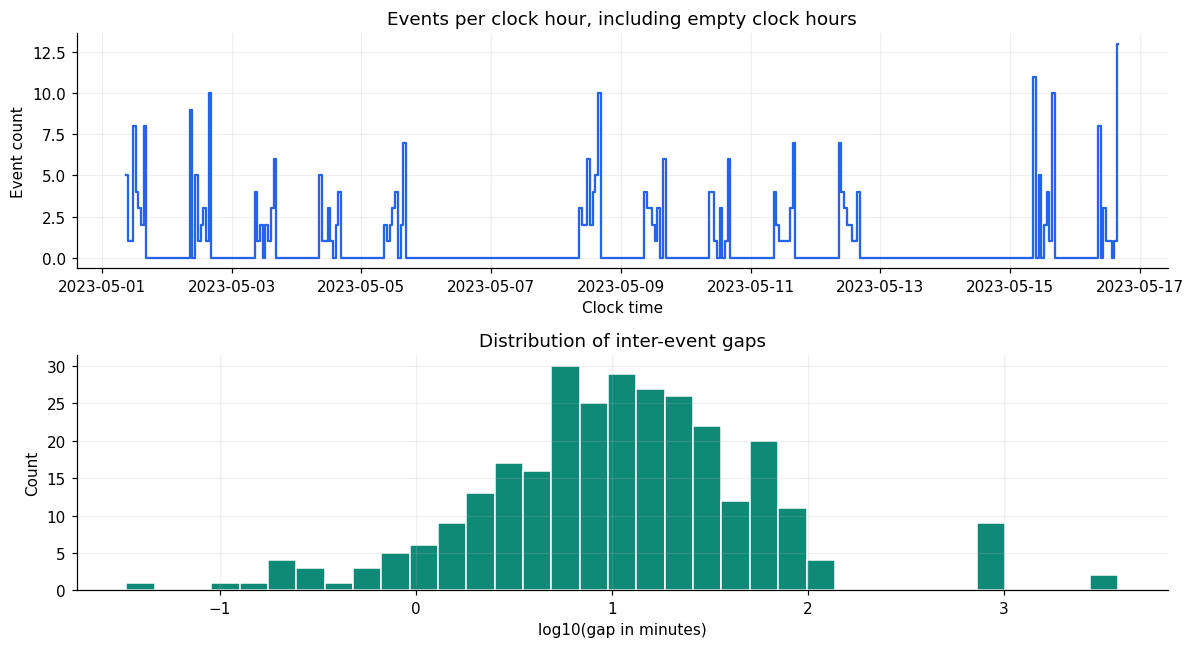

,timestamp,gap_minutes
239,2023-05-15 09:05:00,3852.366667
120,2023-05-08 09:06:50,3849.050000
63,2023-05-03 09:27:49,990.816667
154,2023-05-09 09:21:16,984.466667
272,2023-05-16 09:02:51,976.100000
32,2023-05-02 09:06:35,971.783333


重复时间戳行数: 2


In [32]:
v18 = events.sort_values("timestamp").copy()
v18["gap_minutes"] = v18["timestamp"].diff().dt.total_seconds() / 60
counts = v18.set_index("timestamp")["value"].resample("1h").size()
# 分开看相邻事件间隔；过夜/周末本来就会很长，需要业务日历解释。
plt.figure(figsize=(11, 6))
plt.subplot(2, 1, 1)
plt.plot(counts.index, counts, drawstyle="steps-mid", color=COLORS[0])
plt.title("Events per clock hour, including empty clock hours")
plt.ylabel("Event count")
plt.xlabel("Clock time")
positive_gaps = v18.loc[v18["gap_minutes"].gt(0), "gap_minutes"]
plt.subplot(2, 1, 2)
plt.hist(np.log10(positive_gaps), bins=35, color=COLORS[2], edgecolor="white")
plt.title("Distribution of inter-event gaps")
plt.xlabel("log10(gap in minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
display(v18[["timestamp", "gap_minutes"]].nlargest(6, "gap_minutes"))
print("重复时间戳行数:", v18.duplicated(["timestamp", "asset"], keep=False).sum())

**如何读结果：** 上图的零小时包含夜间、周末等非活跃时段；下图对间隔取 log10，值为 2 表示 100 分钟。最长间隔表帮助区分合理关闭与意外停报。

**常见误判：** 固定行数 rolling 不是固定时间跨度。事件平均值会对高频活跃时期赋予更高权重；若想表达每小时典型水平，应先按时间格聚合并说明空格如何处理。

## 场景 → 推荐图 → 必须一起报告

| 场景 | 优先图 | 最低限度的补充 |
|---|---|---|
| 单序列刚拿到手 | V01 水平/变化 | 单位、频率、时间范围 |
| 多对象规模不同 | V02 共同起点分面 | 起点与共同样本范围 |
| 缺失或断档 | V03 热图 + V04 覆盖 | 缺整行/缺字段、日历与分母 |
| 极端值、厚尾 | V05 分布/ECDF + V06 时间标记 | 尾部分位数、原始记录核对 |
| 风险或均值随时间变 | V07 滚动图 + V15 切分背景 | 窗口、时点、阶段是否事前已知 |
| 两序列同时变化 | V08 滚动相关 | 共同样本数、收益口径 |
| 多序列相关 | V09 矩阵 | pairwise 样本量/期间 |
| 历史特征与未来目标 | V10 散点 + V16 分位组 | 时间对齐、训练边界、测试样本量 |
| 序列有“记忆” | V11 ACF | lag 的单位、非平稳性、参考界限局限 |
| 周内/日内模式 | V12 箱线图 | 每组样本量、时间地区、跨期验证 |
| 月度表现一览 | V13 年月热图 | 完整月检查、有效日数 |
| 量价或不同单位变量 | V14 共享时间轴分图 | 变量单位与可用时刻 |
| 路径损失风险 | V17 净值/回撤 | 初始净值、缺失策略、是否恢复 |
| 事件观测不规则 | V18 计数/间隔 | 活跃日历、零事件与采集失败 |

### 现场 30 分钟 EDA 顺序

1. **0–5 分钟**：写下粒度、目标、单位、可用时点；用 D01–D03 审计主键和字段。
2. **5–12 分钟**：用 D04–D06 解释缺失、日历和极值，保留处理日志。
3. **12–22 分钟**：选 V01、V03、V05 和最相关的一张关系图；每张图写一条结论和一个替代解释。
4. **22–30 分钟**：确定 D11 的未来标签和时间切分，记录最简单 baseline，列出下一步需要检验的一个主要假设。

### 复制代码之前的检查

- 这个模板的行粒度、频率、单位和信息时点，与当前题目是否一致？
- 连接是否有 `validate` 或行数断言？窗口是否按对象隔离？
- NaN 的含义是否已明确？是否无意填成 0 或用未来值补过去？
- 训练、验证、测试的角色是否固定？数据预处理参数是否只从训练期学习？
- 图上的每条线/柱子用了多少样本？有无遗漏最差时期或不完整月份？

### 官方参考文档

这些链接方便现场查具体参数；仓库模板以 Python 3.8 / pandas 1.5 系列兼容语法为目标，运行时仍先查看现场实际版本。

- [pandas 1.5：缺失数据](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/missing_data.html)
- [pandas 1.5：时间序列与日期](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/timeseries.html)
- [pandas 1.5：merge_asof](https://pandas.pydata.org/pandas-docs/version/1.5/reference/api/pandas.merge_asof.html)
- [pandas 1.5：groupby](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/groupby.html)
- [pandas 1.5：窗口计算](https://pandas.pydata.org/pandas-docs/version/1.5/user_guide/window.html)
- [pandas 1.5：pct_change](https://pandas.pydata.org/pandas-docs/version/1.5/reference/api/pandas.DataFrame.pct_change.html)
- [Matplotlib 3.7：绘图示例集](https://matplotlib.org/3.7.5/gallery/index.html)
- [NumPy 1.24：统计函数](https://numpy.org/doc/1.24/reference/routines.statistics.html)
- [scikit-learn：数据泄漏与预处理陷阱](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

本 notebook 不宣称任何图形关系是真实金融市场规律，也不声称这些模板覆盖特定公司的真实题目。下一部分可以在此基础上添加建模、验证和回测。